# Visualization Notebook — Poster & Report Figures

All figures for the neural genomic compressor project.
Consistent styling, publication-quality output.

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LN2 = math.log(2)
def loss_to_bpb(loss):
    return loss / LN2 / 6

# ── Consistent style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

SAVE_DIR = '/content/figures'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Figures will be saved to: {SAVE_DIR}')

Device: cuda
Figures will be saved to: /content/figures


In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!cp /content/drive/MyDrive/genomic_compressor/chr22_hidden_states.pt /content/
!cp /content/drive/MyDrive/genomic_compressor/sae_checkpoints/sae_epoch_4.pt /content/
!cp /content/drive/MyDrive/genomic_compressor/hidden_states_norm_stats.pt /content/
!cp /content/drive/MyDrive/genomic_compressor/annotations.py /content/
!cp /content/drive/MyDrive/genomic_compressor/model.py /content/
!cp /content/drive/MyDrive/genomic_compressor/tokenizer.py /content/
!cp -r /content/drive/MyDrive/genomic_compressor/annotations/ /content/annotations/
!cp -r /content/drive/MyDrive/genomic_compressor/data/ /content/data/
print('Files copied.')

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/Shareddrives': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/genomic_compressor/chr22_hidden_states.pt': No such file or directory
cp: cannot stat '/content/drive/MyDrive/genomic_compressor/sae_checkpoints/sae_epoch_4.pt': No such file or directory
cp: cannot stat '/content/drive/MyDrive/genomic_compressor/hidden_states_norm_stats.pt': No such file or directory
cp: cannot stat '/content/drive/MyDrive/genomic_compressor/annotations.py': No such file or directory
cp: cannot stat '/content/drive/MyDrive/genomic_compressor/model.py': No such file or directory
cp: cannot stat '/content/drive/MyDrive/genomic_compressor/tokenizer.py': No such file or directory
cp: cannot stat '/content/drive/MyDrive/genomic_compressor

In [ ]:
# ── Load everything ──

# SAE
class SAE(nn.Module):
    def __init__(self, l1_coeff=0.0, input_dim=512, dict_size=8192):
        super().__init__()
        self.l1_coeff = l1_coeff
        self.input_dim = input_dim
        self.dict_size = dict_size
        self.encoder = nn.Sequential(nn.Linear(input_dim, dict_size), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(dict_size, input_dim))
    def encode(self, x):
        return self.encoder(x)

sae = SAE(input_dim=512, dict_size=8192).to(device)
sae_ckpt = torch.load('/content/sae_epoch_4.pt', map_location=device, weights_only=False)
sae.load_state_dict(sae_ckpt['model_state_dict'])
sae.eval()

# Hidden states
hidden_states = torch.load('/content/chr22_hidden_states.pt', map_location='cpu').float()
norm_stats = torch.load('/content/hidden_states_norm_stats.pt', map_location='cpu')
norm_mean = norm_stats['mean']
norm_std = norm_stats['std']
hidden_states = (hidden_states - norm_mean) / norm_std
num_tokens = hidden_states.shape[0]

# Annotations
from annotations import AnnotationIndex
ann = AnnotationIndex('/content/annotations/', '/content/data/chr22_ref_positions_tokens.npy')

print(f'\nAll data loaded. {num_tokens:,} tokens.')

Coordinate map: 6,526,630 tokens
  Ref range: 10,510,000 – 50,808,460
  RepeatMasker: 79,521 regions loaded
  CpG islands:  737 regions loaded
  GENCODE:      62,114 features loaded

Annotation index built:
  Labels:           104
  Annotated tokens: 5,710,904
    CDS                             129,714 tokens
    CpG_island                       99,107 tokens
    DNA                             173,416 tokens
    DNA/DNA                             242 tokens
    DNA/MULE-MuDR                     2,641 tokens
    DNA/PIF-Harbinger                     8 tokens
    DNA/PiggyBac                      1,135 tokens
    DNA/PiggyBac?                        68 tokens
    DNA/TcMar                           112 tokens
    DNA/TcMar-Mariner                 2,940 tokens
    DNA/TcMar-Pogo                       10 tokens
    DNA/TcMar-Tc2                     3,010 tokens
    DNA/TcMar-Tigger                 55,674 tokens
    DNA/hAT                           2,736 tokens
    DNA/hAT-Ac           

---
## Figure 1: Compression Comparison

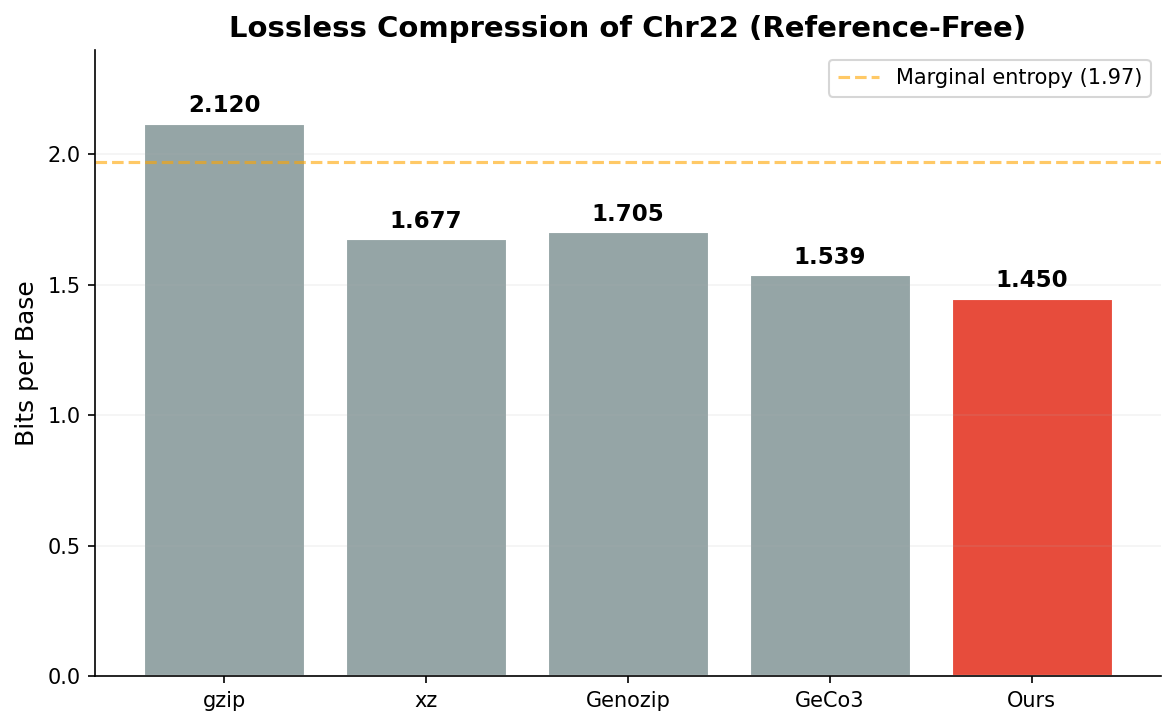

Saved Figure 1.


In [ ]:
compressors = ['gzip', 'xz', 'Genozip', 'GeCo3', 'Ours']
bpb_values = [2.120, 1.677, 1.705, 1.539, 1.450]
colors = ['#95a5a6', '#95a5a6', '#95a5a6', '#95a5a6', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(compressors, bpb_values, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, bpb_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Bits per Base')
ax.set_title('Lossless Compression of Chr22 (Reference-Free)')
ax.set_ylim(0, 2.4)
ax.axhline(y=1.97, color='orange', linestyle='--', alpha=0.6, label='Marginal entropy (1.97)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.15, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig1_compression_comparison.png')
plt.savefig(f'{SAVE_DIR}/fig1_compression_comparison.pdf')
plt.show()
print('Saved Figure 1.')

---
## Figure 2: Feature Frequency Distribution

Computing feature frequencies...


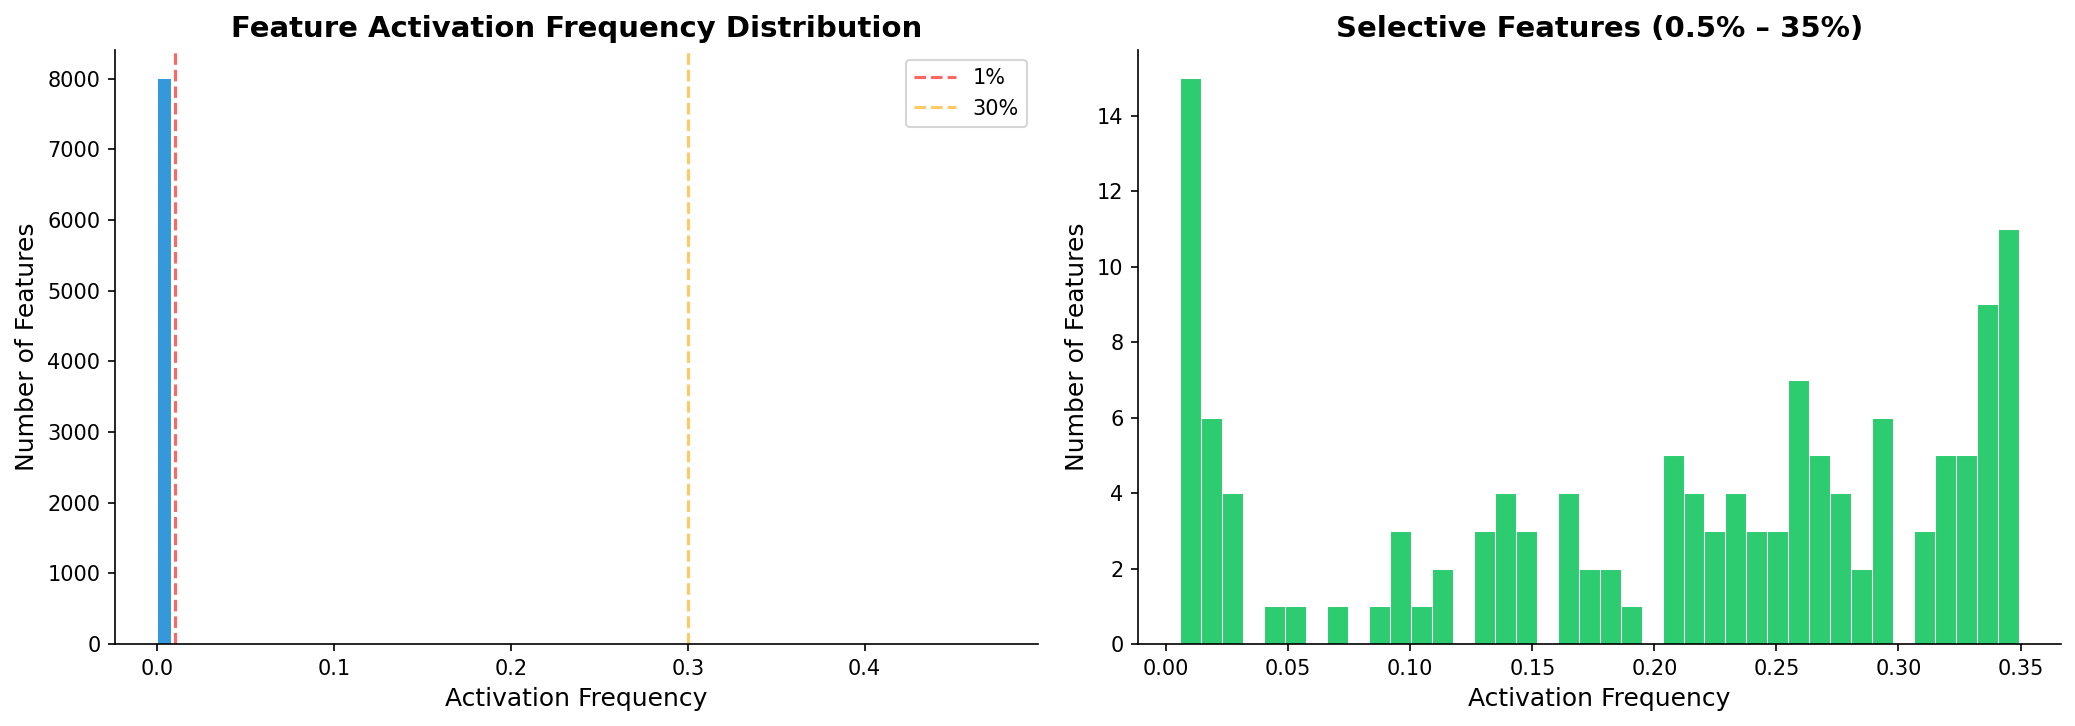

Alive features: 8,192 / 8192
Saved Figure 2.


In [ ]:
# Compute feature frequencies
print('Computing feature frequencies...')
feature_count = torch.zeros(8192)
with torch.no_grad():
    for i in range(0, num_tokens, 8192):
        batch = hidden_states[i:i+8192].to(device)
        z = sae.encode(batch).cpu()
        feature_count += (z > 0).float().sum(dim=0)

feature_freq = feature_count / num_tokens
alive_mask = feature_freq > 0
alive_freqs = feature_freq[alive_mask].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(alive_freqs, bins=60, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Activation Frequency')
axes[0].set_ylabel('Number of Features')
axes[0].set_title('Feature Activation Frequency Distribution')
axes[0].axvline(x=0.01, color='red', linestyle='--', alpha=0.6, label='1%')
axes[0].axvline(x=0.30, color='orange', linestyle='--', alpha=0.6, label='30%')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Zoom into selective range
selective_freqs = alive_freqs[(alive_freqs > 0.005) & (alive_freqs < 0.35)]
axes[1].hist(selective_freqs, bins=40, color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Activation Frequency')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Selective Features (0.5% – 35%)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig2_feature_frequency.png')
plt.savefig(f'{SAVE_DIR}/fig2_feature_frequency.pdf')
plt.show()
print(f'Alive features: {alive_mask.sum().item():,} / 8192')
print('Saved Figure 2.')

---
## Figure 3: Genome Browser Tracks — Alu Detector

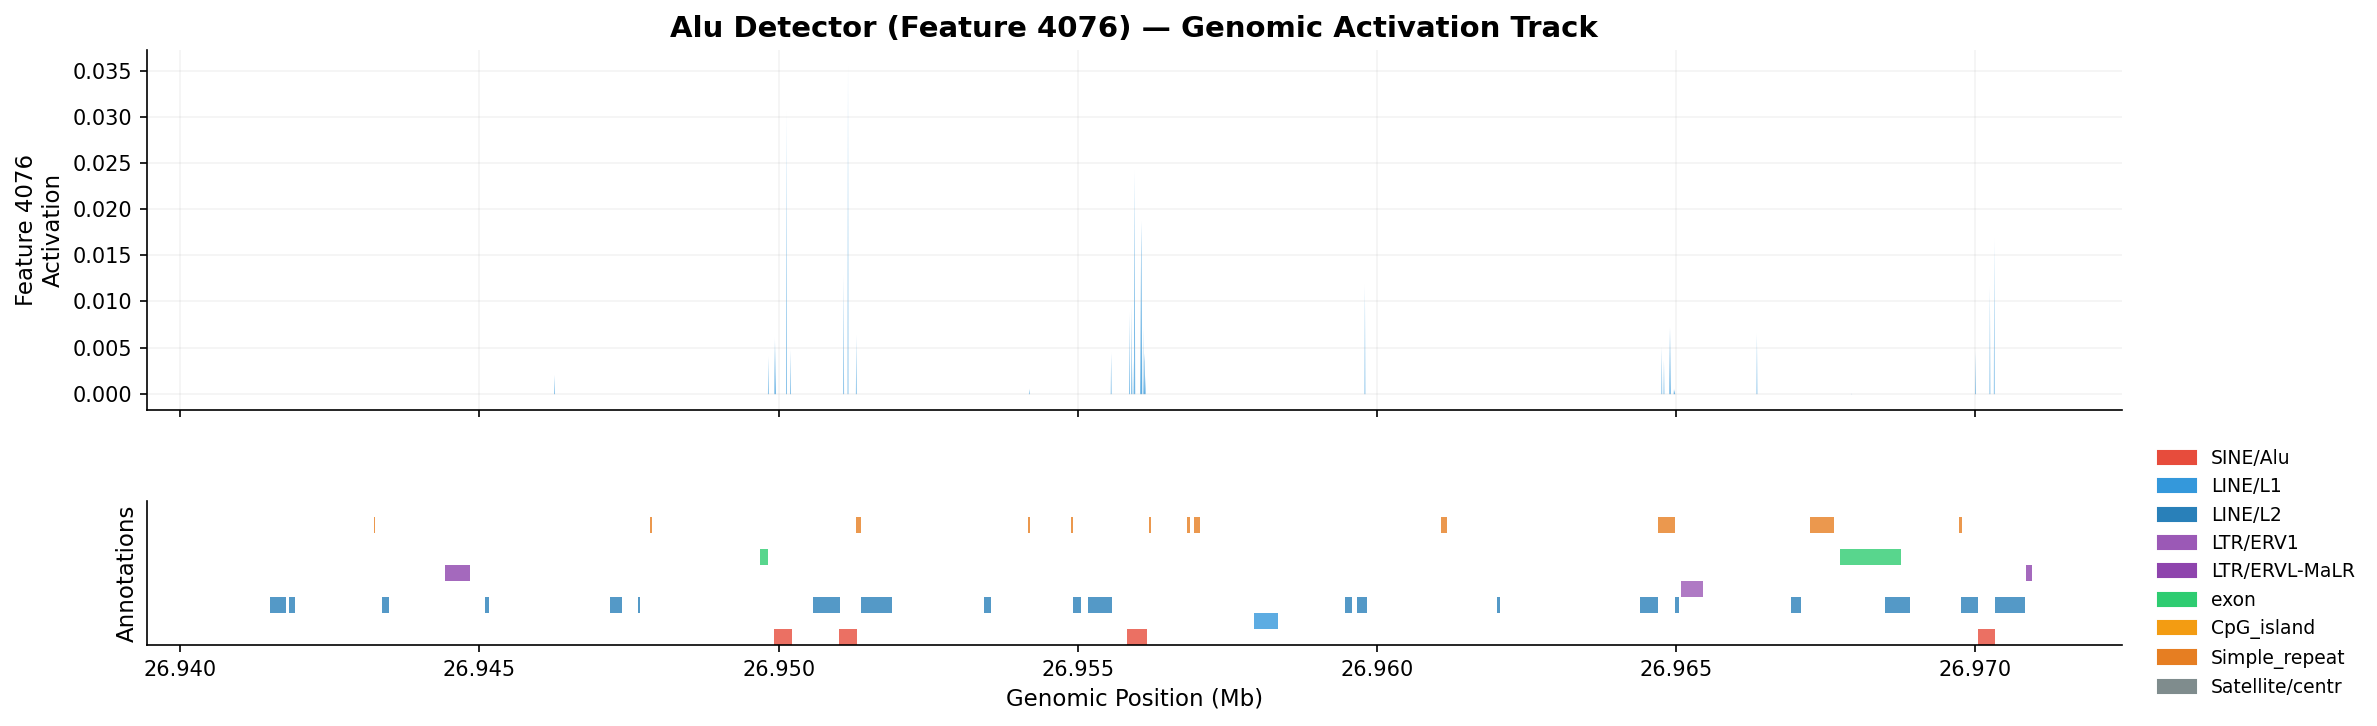

Saved Figure 3a.


In [ ]:
def get_feature_activations_region(sae, hidden_states, feature_idx, start, end, device):
    """Get activations for one feature in a region."""
    region_hidden = hidden_states[start:end].to(device)
    with torch.no_grad():
        z = sae.encode(region_hidden)
        return z[:, feature_idx].cpu().numpy()


def plot_genome_track(feature_idx, feature_name, region_start, region_end,
                      sae, hidden_states, ann, device, save_name=None):
    """Publication-quality genome browser track."""
    feat_act = get_feature_activations_region(
        sae, hidden_states, feature_idx, region_start, region_end, device
    )

    token_indices = np.arange(region_start, region_end)
    ref_positions = np.array([ann.get_ref_position(int(t)) for t in token_indices])
    ref_mb = ref_positions / 1e6  # Convert to megabases

    annotation_colors = {
        'SINE/Alu': '#e74c3c',
        'LINE/L1': '#3498db',
        'LINE/L2': '#2980b9',
        'LTR/ERV1': '#9b59b6',
        'LTR/ERVL-MaLR': '#8e44ad',
        'exon': '#2ecc71',
        'CpG_island': '#f39c12',
        'Simple_repeat': '#e67e22',
        'Satellite/centr': '#7f8c8d',
    }

    fig, axes = plt.subplots(2, 1, figsize=(16, 5),
                             height_ratios=[3, 1.2], sharex=True)

    # Activation track
    axes[0].fill_between(ref_mb, feat_act, alpha=0.8, color='#3498db', linewidth=0)
    axes[0].set_ylabel(f'Feature {feature_idx}\nActivation', fontsize=11)
    axes[0].set_title(f'{feature_name} — Genomic Activation Track', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.15)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # Annotation track
    legend_patches = []
    y_pos = 0
    n_labels = len(annotation_colors)
    for label, color in annotation_colors.items():
        annotated_set = set(ann.get_tokens(label).tolist())
        for t_idx, ref_pos in zip(token_indices, ref_mb):
            if int(t_idx) in annotated_set:
                axes[1].axvspan(
                    ref_pos, ref_pos + 6/1e6,
                    ymin=y_pos/n_labels, ymax=(y_pos+1)/n_labels,
                    alpha=0.8, color=color, linewidth=0
                )
        legend_patches.append(mpatches.Patch(color=color, label=label))
        y_pos += 1

    axes[1].set_ylabel('Annotations', fontsize=11)
    axes[1].set_xlabel('Genomic Position (Mb)', fontsize=11)
    axes[1].set_yticks([])
    axes[1].legend(handles=legend_patches, loc='center left',
                   bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    if save_name:
        plt.savefig(f'{SAVE_DIR}/{save_name}.png')
        plt.savefig(f'{SAVE_DIR}/{save_name}.pdf')
    plt.show()


# Find dense Alu region
def find_dense_region(sae, hidden_states, feature_idx, ann, label, window=5000, device='cuda'):
    """Find the region with the most feature activations overlapping an annotation."""
    annotated = sorted(ann.get_tokens(label).tolist())
    # Sample from the middle
    center = annotated[len(annotated) // 3]
    return max(0, center - window // 2), min(num_tokens, center + window // 2)


# Alu detector track
alu_start, alu_end = find_dense_region(sae, hidden_states, 4076, ann, 'SINE/Alu')
plot_genome_track(4076, 'Alu Detector (Feature 4076)', alu_start, alu_end,
                  sae, hidden_states, ann, device, save_name='fig3a_alu_detector_track')
print('Saved Figure 3a.')

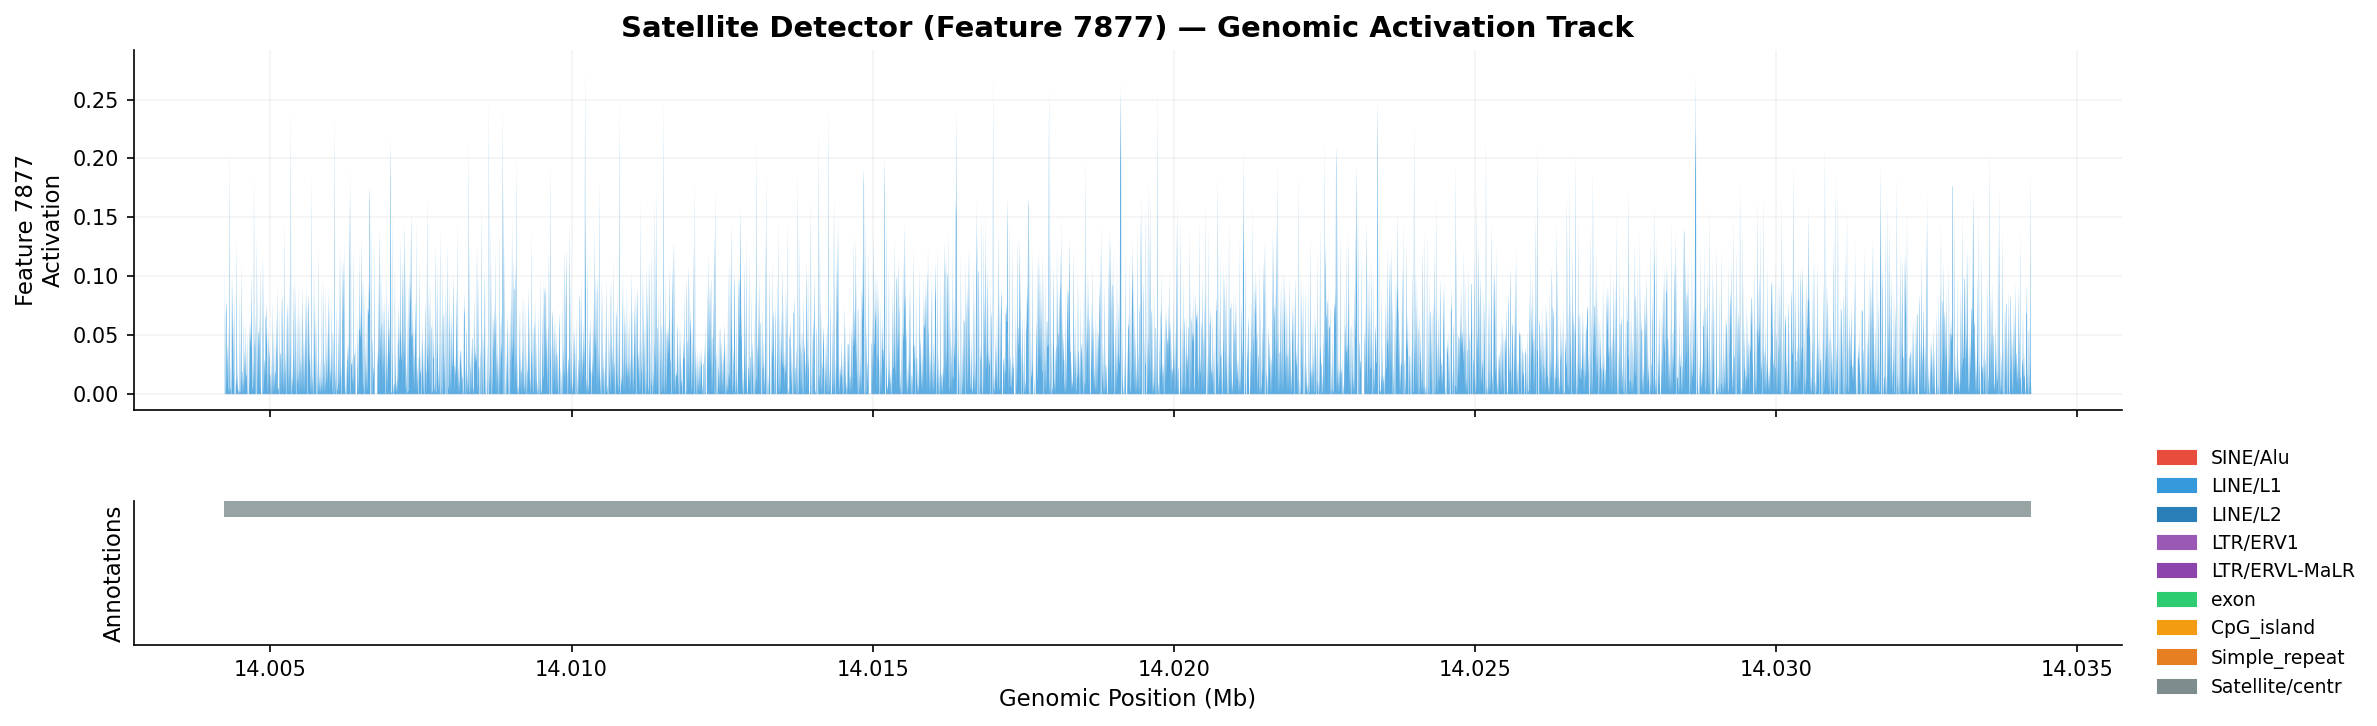

Saved Figure 3b.


In [ ]:
# Satellite detector track
sat_tokens = sorted(ann.get_tokens('Satellite/centr').tolist())
sat_center = sat_tokens[len(sat_tokens) // 2]
sat_start = max(0, sat_center - 2500)
sat_end = min(num_tokens, sat_center + 2500)

plot_genome_track(7877, 'Satellite Detector (Feature 7877)', sat_start, sat_end,
                  sae, hidden_states, ann, device, save_name='fig3b_satellite_detector_track')
print('Saved Figure 3b.')

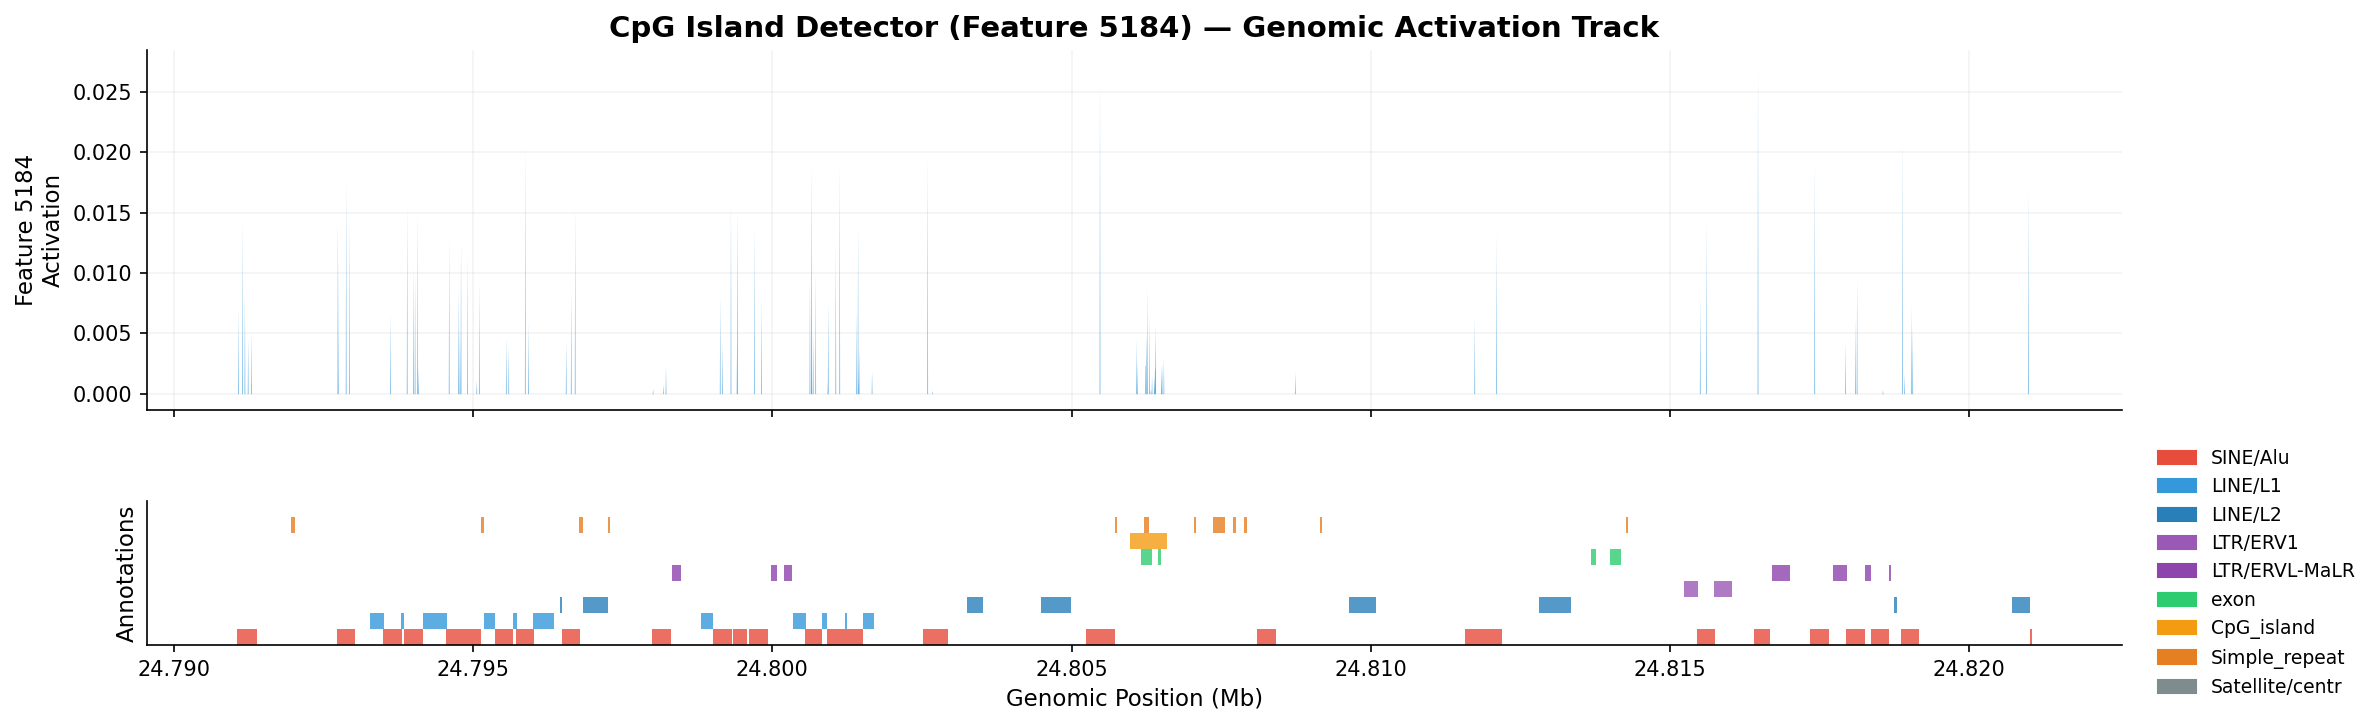

Saved Figure 3c.


In [ ]:
# CpG island detector track
cpg_tokens = sorted(ann.get_tokens('CpG_island').tolist())
cpg_center = cpg_tokens[len(cpg_tokens) // 3]
cpg_start = max(0, cpg_center - 2500)
cpg_end = min(num_tokens, cpg_center + 2500)

plot_genome_track(5184, 'CpG Island Detector (Feature 5184)', cpg_start, cpg_end,
                  sae, hidden_states, ann, device, save_name='fig3c_cpg_detector_track')
print('Saved Figure 3c.')

---
## Figure 4: Feature Catalog — Best Detectors Per Category

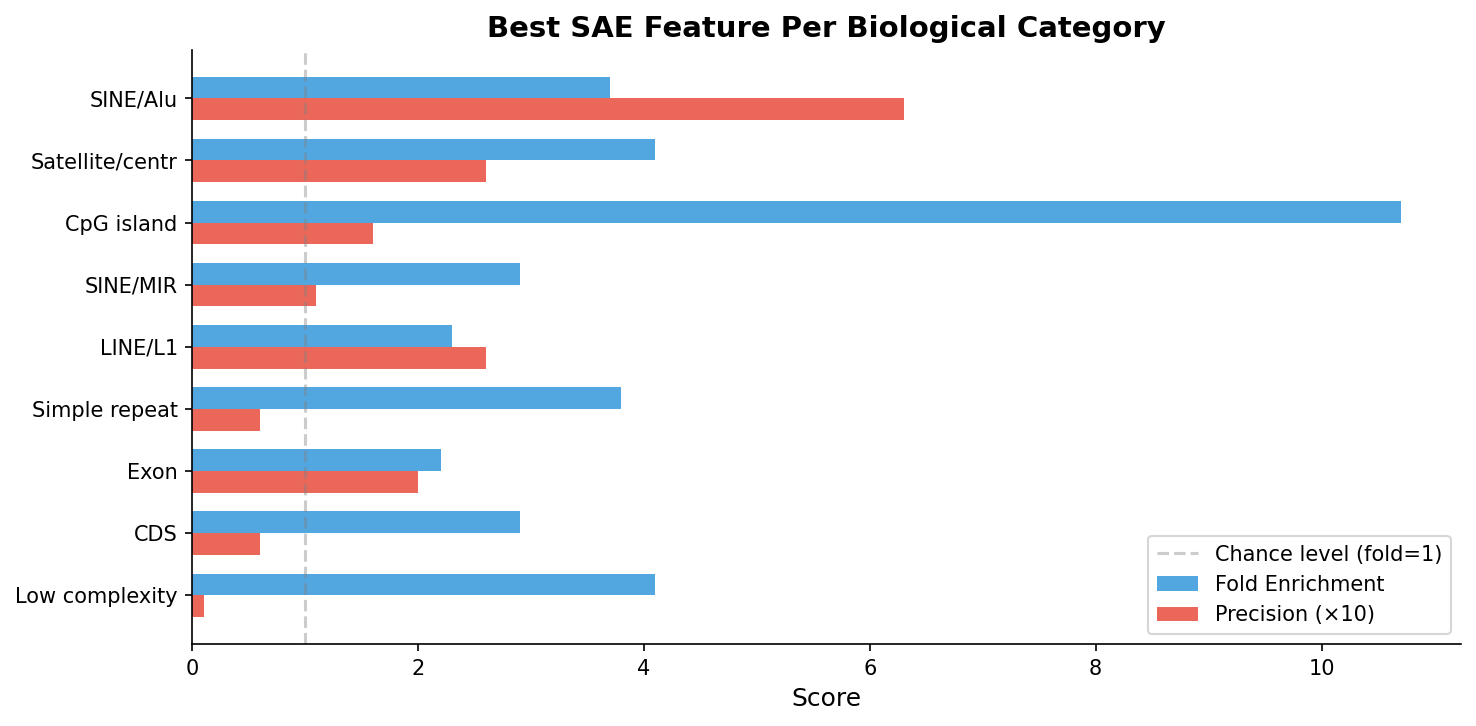

Saved Figure 4.


In [ ]:
# Hardcoded from analysis results
catalog_data = [
    ('SINE/Alu',       4076, 3.7, 0.63, 0.08),
    ('Satellite/centr', 7877, 4.1, 0.26, 0.67),
    ('CpG island',     5184, 10.7, 0.16, 0.13),
    ('SINE/MIR',       3890, 2.9, 0.11, 0.06),
    ('LINE/L1',        4093, 2.3, 0.26, 0.07),
    ('Simple repeat',  4093, 3.8, 0.06, 0.11),
    ('Exon',           7095, 2.2, 0.20, 0.02),
    ('CDS',            7095, 2.9, 0.06, 0.03),
    ('Low complexity',  6868, 4.1, 0.01, 0.08),
]

fig, ax = plt.subplots(figsize=(10, 5))

labels = [d[0] for d in catalog_data]
folds = [d[2] for d in catalog_data]
precs = [d[3] for d in catalog_data]

y_pos = np.arange(len(labels))
width = 0.35

bars1 = ax.barh(y_pos - width/2, folds, width, label='Fold Enrichment',
                color='#3498db', alpha=0.85)
bars2 = ax.barh(y_pos + width/2, [p * 10 for p in precs], width,
                label='Precision (×10)', color='#e74c3c', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Score')
ax.set_title('Best SAE Feature Per Biological Category')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.4, label='Chance level (fold=1)')
ax.legend(loc='lower right')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig4_feature_catalog.png')
plt.savefig(f'{SAVE_DIR}/fig4_feature_catalog.pdf')
plt.show()
print('Saved Figure 4.')

---
## Figure 5: Ablation Results

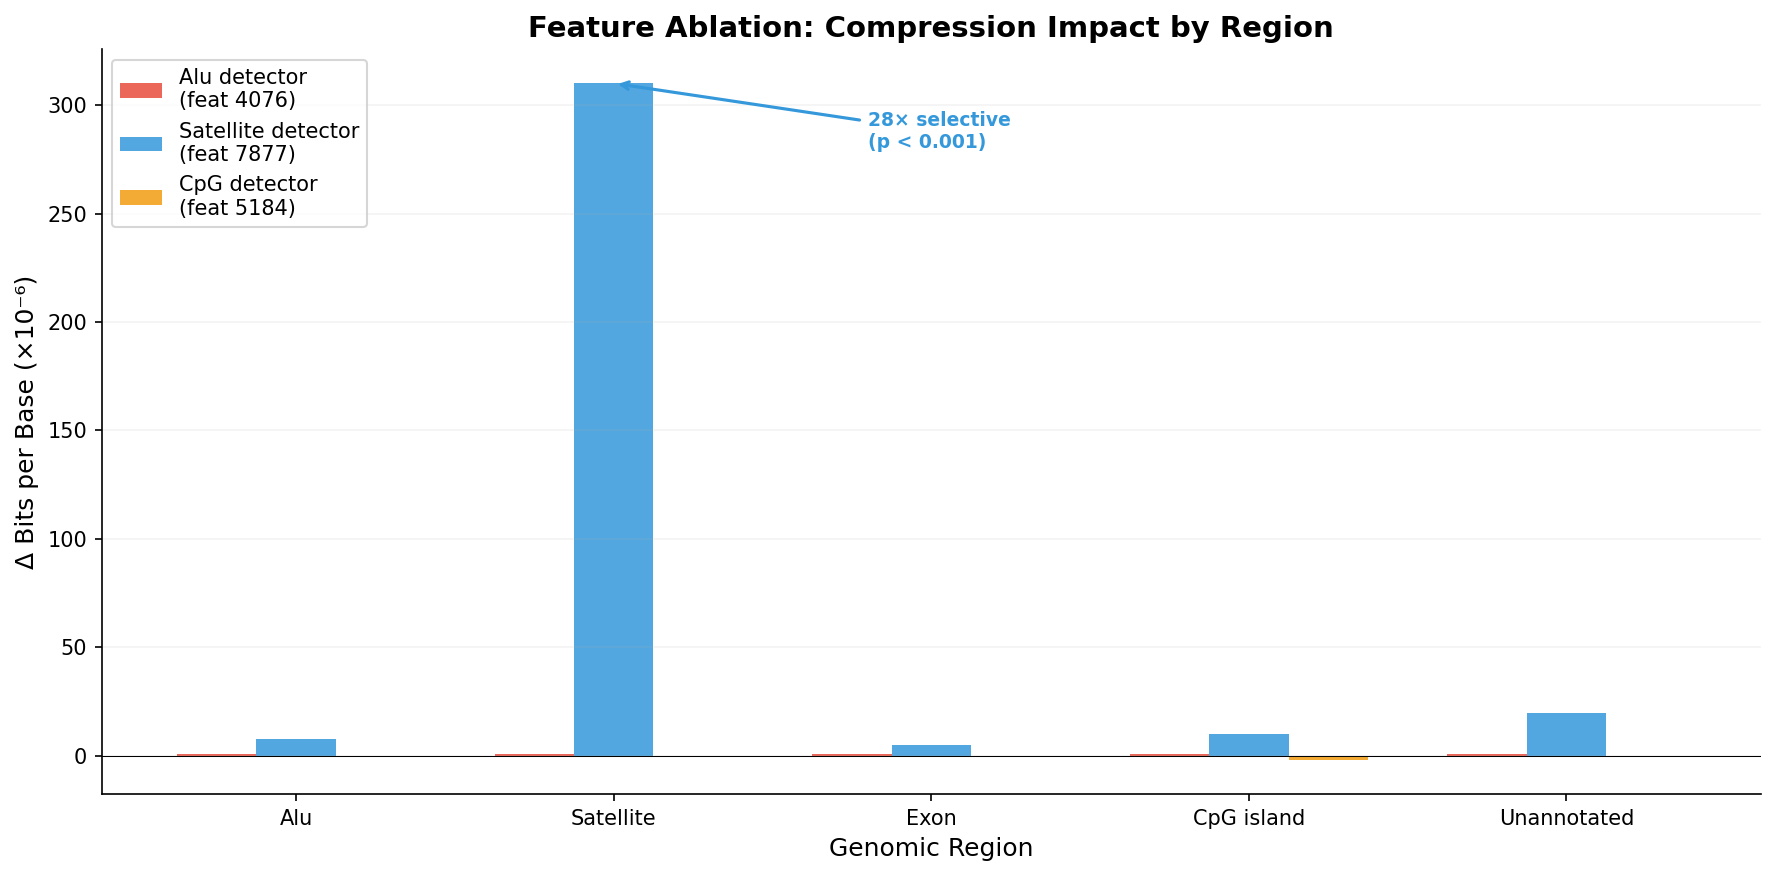

Saved Figure 5.


In [ ]:
# Hardcoded from ablation experiments
ablation_data = {
    'Alu detector\n(feat 4076)': {
        'Alu': 0.000001, 'Satellite': 0.000001, 'Exon': 0.000001,
        'CpG island': 0.000001, 'Unannotated': 0.000001,
    },
    'Satellite detector\n(feat 7877)': {
        'Alu': 0.000008, 'Satellite': 0.000310, 'Exon': 0.000005,
        'CpG island': 0.000010, 'Unannotated': 0.000020,
    },
    'CpG detector\n(feat 5184)': {
        'Alu': 0.000000, 'Satellite': 0.000000, 'Exon': 0.000000,
        'CpG island': -0.000002, 'Unannotated': 0.000000,
    },
}

regions = ['Alu', 'Satellite', 'Exon', 'CpG island', 'Unannotated']
x = np.arange(len(regions))
width = 0.25
colors = ['#e74c3c', '#3498db', '#f39c12']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (feat_name, deltas) in enumerate(ablation_data.items()):
    vals = [deltas[r] * 1e6 for r in regions]  # Scale to micro-bpb
    ax.bar(x + i * width, vals, width, label=feat_name,
           color=colors[i], alpha=0.85)

ax.set_xlabel('Genomic Region')
ax.set_ylabel('Δ Bits per Base (×10⁻⁶)')
ax.set_title('Feature Ablation: Compression Impact by Region')
ax.set_xticks(x + width)
ax.set_xticklabels(regions)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.15, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate the satellite bar
sat_bar_x = x[1] + 1 * width
ax.annotate('28× selective\n(p < 0.001)',
            xy=(sat_bar_x, 310), xytext=(sat_bar_x + 0.8, 280),
            fontsize=9, fontweight='bold', color='#3498db',
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.5))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig5_ablation_results.png')
plt.savefig(f'{SAVE_DIR}/fig5_ablation_results.pdf')
plt.show()
print('Saved Figure 5.')

---
## Figure 6: Feature Steering Results

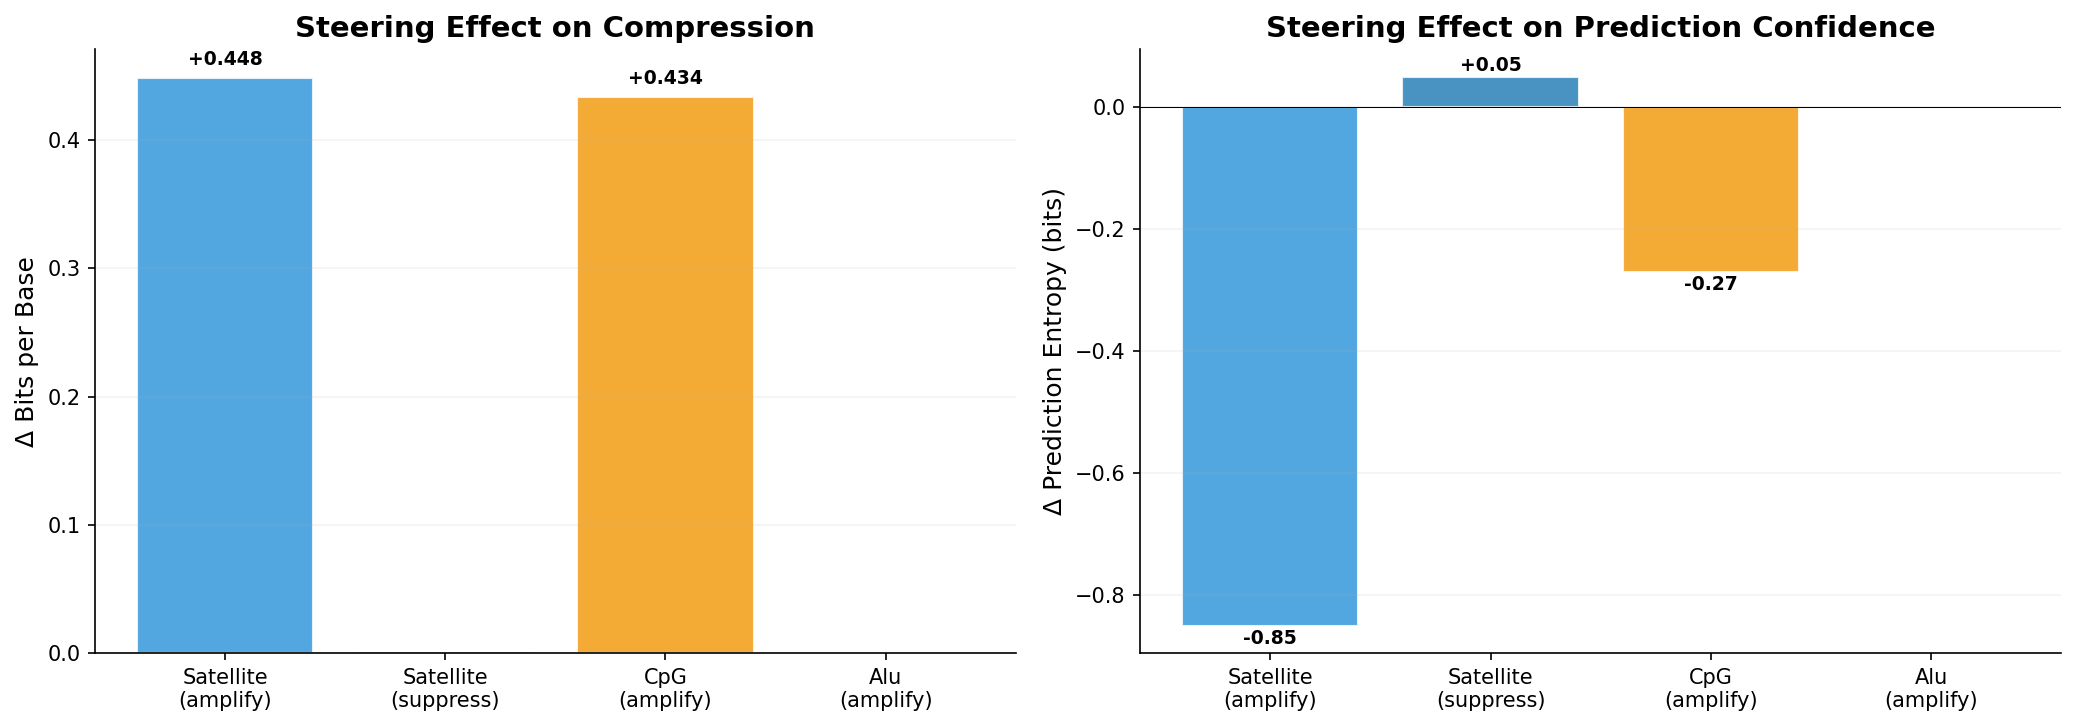

Saved Figure 6.


In [ ]:
# Hardcoded from steering experiments
steering_data = {
    'Satellite amplification\n(non-satellite region)': {
        'scales': [0.0, 1.0, 50.0, 100.0, 500.0, 1000.0, 5000.0],
        'bpb_delta': None,  # Will compute from absolute values
        'bpb': [None, 1.6521, None, None, None, None, 2.1004],
        'entropy': [None, 9.40, None, None, None, None, 8.54],
        'color': '#3498db',
    },
    'CpG amplification\n(non-repeat region)': {
        'scales': [0.0, 1.0, 50.0, 100.0, 500.0, 1000.0, 5000.0],
        'bpb': [None, 1.6521, None, None, None, None, 2.0859],
        'entropy': [None, 9.40, None, None, None, None, 9.13],
        'color': '#f39c12',
    },
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Summary bar chart — delta at max scale
exp_names = ['Satellite\n(amplify)', 'Satellite\n(suppress)', 'CpG\n(amplify)', 'Alu\n(amplify)']
bpb_deltas = [+0.4482, +0.0006, +0.4337, +0.0000]
entropy_deltas = [-0.85, +0.05, -0.27, +0.00]
bar_colors = ['#3498db', '#2980b9', '#f39c12', '#e74c3c']

axes[0].bar(exp_names, bpb_deltas, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Δ Bits per Base')
axes[0].set_title('Steering Effect on Compression')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.15, axis='y')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (name, delta) in enumerate(zip(exp_names, bpb_deltas)):
    if abs(delta) > 0.01:
        axes[0].text(i, delta + 0.01, f'{delta:+.3f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(exp_names, entropy_deltas, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Δ Prediction Entropy (bits)')
axes[1].set_title('Steering Effect on Prediction Confidence')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.15, axis='y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for i, (name, delta) in enumerate(zip(exp_names, entropy_deltas)):
    if abs(delta) > 0.01:
        offset = -0.03 if delta < 0 else 0.01
        axes[1].text(i, delta + offset, f'{delta:+.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig6_steering_results.png')
plt.savefig(f'{SAVE_DIR}/fig6_steering_results.pdf')
plt.show()
print('Saved Figure 6.')

---
## Figure 7: Steering Dose-Response Curves

In [ ]:
# Rerun satellite steering to get full curve
from model import DecoderOnlyTransformer

transformer = DecoderOnlyTransformer(
    vocab_size=4096, embed_dim=512, num_heads=8,
    num_layers=12, bias=True, tie_weights=True,
).to(device)
t_ckpt = torch.load(
    '/content/drive/MyDrive/genomic_compressor/checkpoints/best_model.pt',
    map_location=device, weights_only=False
)
transformer.load_state_dict(t_ckpt['model_state_dict'])
transformer.eval()

norm_mean_gpu = norm_mean.to(device)
norm_std_gpu = norm_std.to(device)

chr22_tokens = np.load('/content/data/chr22.npy')

# Find regions
all_repeat_tokens = set()
for label in ['SINE', 'LINE', 'LTR', 'DNA', 'Satellite', 'Simple_repeat']:
    all_repeat_tokens.update(ann.get_tokens(label).tolist())
non_repeat_tokens = set(range(num_tokens)) - all_repeat_tokens

def find_contiguous_region(token_set):
    sorted_tokens = sorted(token_set)
    best_start, best_length = sorted_tokens[0], 1
    current_start, current_length = sorted_tokens[0], 1
    for i in range(1, len(sorted_tokens)):
        if sorted_tokens[i] == sorted_tokens[i-1] + 1:
            current_length += 1
            if current_length > best_length:
                best_length = current_length
                best_start = current_start
        else:
            current_start = sorted_tokens[i]
            current_length = 1
    return best_start, best_length

nonrep_start, _ = find_contiguous_region(non_repeat_tokens)
NONREP_REGION = (nonrep_start, nonrep_start + 512)

print(f'Non-repeat region: {NONREP_REGION}')
print('Transformer loaded for steering curves.')

Non-repeat region: (1451125, 1451637)
Transformer loaded for steering curves.


In [ ]:
class FeatureSteeringHook:
    def __init__(self, sae, feature_idx, norm_mean, norm_std, scale=1.0, target_layer=11):
        self.sae = sae
        self.feature_idx = feature_idx
        self.norm_mean = norm_mean
        self.norm_std = norm_std
        self.scale = scale
        self.target_layer = target_layer
        self.handle = None

    def hook_fn(self, module, input, output):
        x, new_k, new_v = output
        with torch.no_grad():
            x_normed = (x - self.norm_mean) / self.norm_std
            z = self.sae.encode(x_normed)
            original_act = z[:, :, self.feature_idx].clone()
            feature_direction = self.sae.decoder[0].weight[:, self.feature_idx]
            original_contribution = (original_act.unsqueeze(-1) * feature_direction) * self.norm_std
            scaled_contribution = (original_act.unsqueeze(-1) * self.scale * feature_direction) * self.norm_std
            x_steered = x - original_contribution + scaled_contribution
        return (x_steered, new_k, new_v)

    def register(self, transformer):
        self.handle = transformer.blocks[self.target_layer].register_forward_hook(self.hook_fn)
        return self

    def remove(self):
        if self.handle:
            self.handle.remove()
            self.handle = None


@torch.no_grad()
def compute_steering_metrics(transformer, tokens, region, device='cuda'):
    start, end = region
    chunk = torch.tensor(tokens[start:end], dtype=torch.long).unsqueeze(0).to(device)
    with torch.amp.autocast('cuda', dtype=torch.float16):
        output = transformer(chunk)
        logits = output.logits.squeeze(0).float()
    probs = F.softmax(logits[:-1], dim=-1)
    targets = torch.tensor(tokens[start + 1:end], dtype=torch.long).to(device)
    per_pos_loss = F.cross_entropy(logits[:-1], targets, reduction='none')
    per_pos_bpb = per_pos_loss.cpu().numpy() / LN2 / 6
    entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1).cpu().numpy()
    return {'mean_bpb': per_pos_bpb.mean(), 'mean_entropy': entropy.mean()}


# Run satellite steering curve
scales = [0.0, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 2000.0, 5000.0]
sat_curve = {}
cpg_curve = {}

for scale in scales:
    if scale == 1.0:
        metrics = compute_steering_metrics(transformer, chr22_tokens, NONREP_REGION, device)
        sat_curve[scale] = metrics
        cpg_curve[scale] = metrics
    else:
        # Satellite
        hook = FeatureSteeringHook(sae, 7877, norm_mean_gpu, norm_std_gpu, scale=scale)
        hook.register(transformer)
        sat_curve[scale] = compute_steering_metrics(transformer, chr22_tokens, NONREP_REGION, device)
        hook.remove()

        # CpG
        hook = FeatureSteeringHook(sae, 5184, norm_mean_gpu, norm_std_gpu, scale=scale)
        hook.register(transformer)
        cpg_curve[scale] = compute_steering_metrics(transformer, chr22_tokens, NONREP_REGION, device)
        hook.remove()

    print(f'  scale={scale:.0f}: sat_bpb={sat_curve[scale]["mean_bpb"]:.4f}, cpg_bpb={cpg_curve[scale]["mean_bpb"]:.4f}')

print('Done.')

  scale=0: sat_bpb=1.6514, cpg_bpb=1.6521
  scale=1: sat_bpb=1.6521, cpg_bpb=1.6521
  scale=10: sat_bpb=1.6680, cpg_bpb=1.6522
  scale=50: sat_bpb=2.4310, cpg_bpb=1.6537
  scale=100: sat_bpb=3.1343, cpg_bpb=1.6586
  scale=500: sat_bpb=2.5326, cpg_bpb=1.7226
  scale=1000: sat_bpb=2.2833, cpg_bpb=1.8016
  scale=2000: sat_bpb=2.2279, cpg_bpb=1.9142
  scale=5000: sat_bpb=2.1004, cpg_bpb=2.0859
Done.


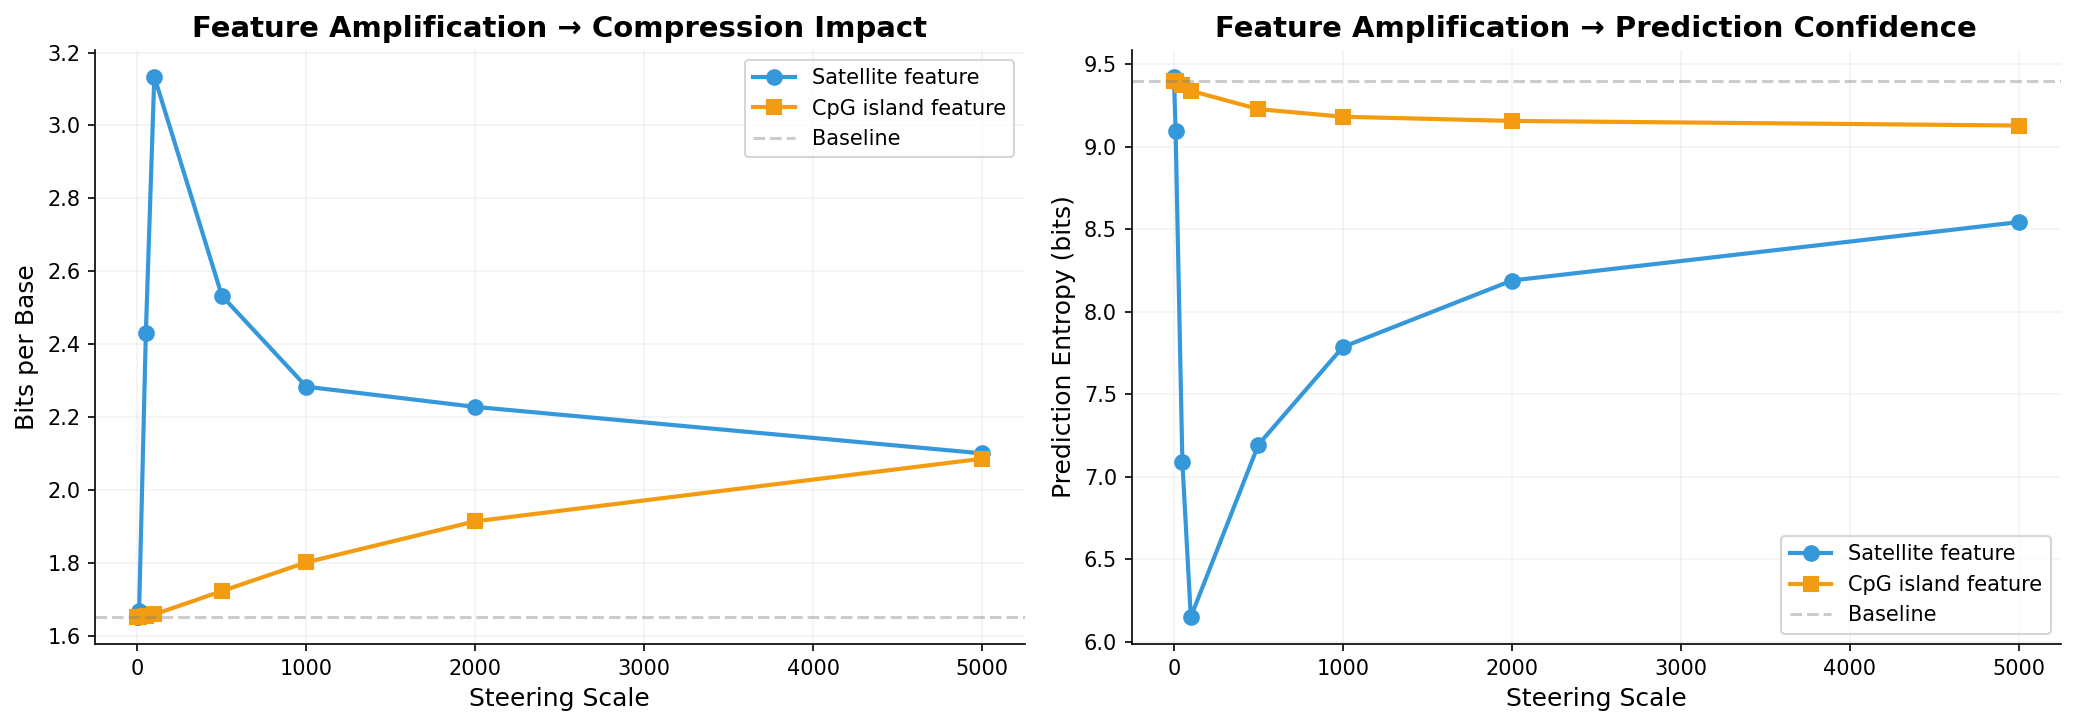

Saved Figure 7.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

s = list(sat_curve.keys())

# BPB curves
axes[0].plot(s, [sat_curve[x]['mean_bpb'] for x in s], 'o-',
             color='#3498db', linewidth=2, markersize=7, label='Satellite feature')
axes[0].plot(s, [cpg_curve[x]['mean_bpb'] for x in s], 's-',
             color='#f39c12', linewidth=2, markersize=7, label='CpG island feature')
axes[0].axhline(y=sat_curve[1.0]['mean_bpb'], color='gray', linestyle='--', alpha=0.4, label='Baseline')
axes[0].set_xlabel('Steering Scale')
axes[0].set_ylabel('Bits per Base')
axes[0].set_title('Feature Amplification → Compression Impact')
axes[0].legend()
axes[0].grid(True, alpha=0.15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Entropy curves
axes[1].plot(s, [sat_curve[x]['mean_entropy'] for x in s], 'o-',
             color='#3498db', linewidth=2, markersize=7, label='Satellite feature')
axes[1].plot(s, [cpg_curve[x]['mean_entropy'] for x in s], 's-',
             color='#f39c12', linewidth=2, markersize=7, label='CpG island feature')
axes[1].axhline(y=sat_curve[1.0]['mean_entropy'], color='gray', linestyle='--', alpha=0.4, label='Baseline')
axes[1].set_xlabel('Steering Scale')
axes[1].set_ylabel('Prediction Entropy (bits)')
axes[1].set_title('Feature Amplification → Prediction Confidence')
axes[1].legend()
axes[1].grid(True, alpha=0.15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig7_steering_dose_response.png')
plt.savefig(f'{SAVE_DIR}/fig7_steering_dose_response.pdf')
plt.show()
print('Saved Figure 7.')

---
## Figure 8: Summary Poster Panel

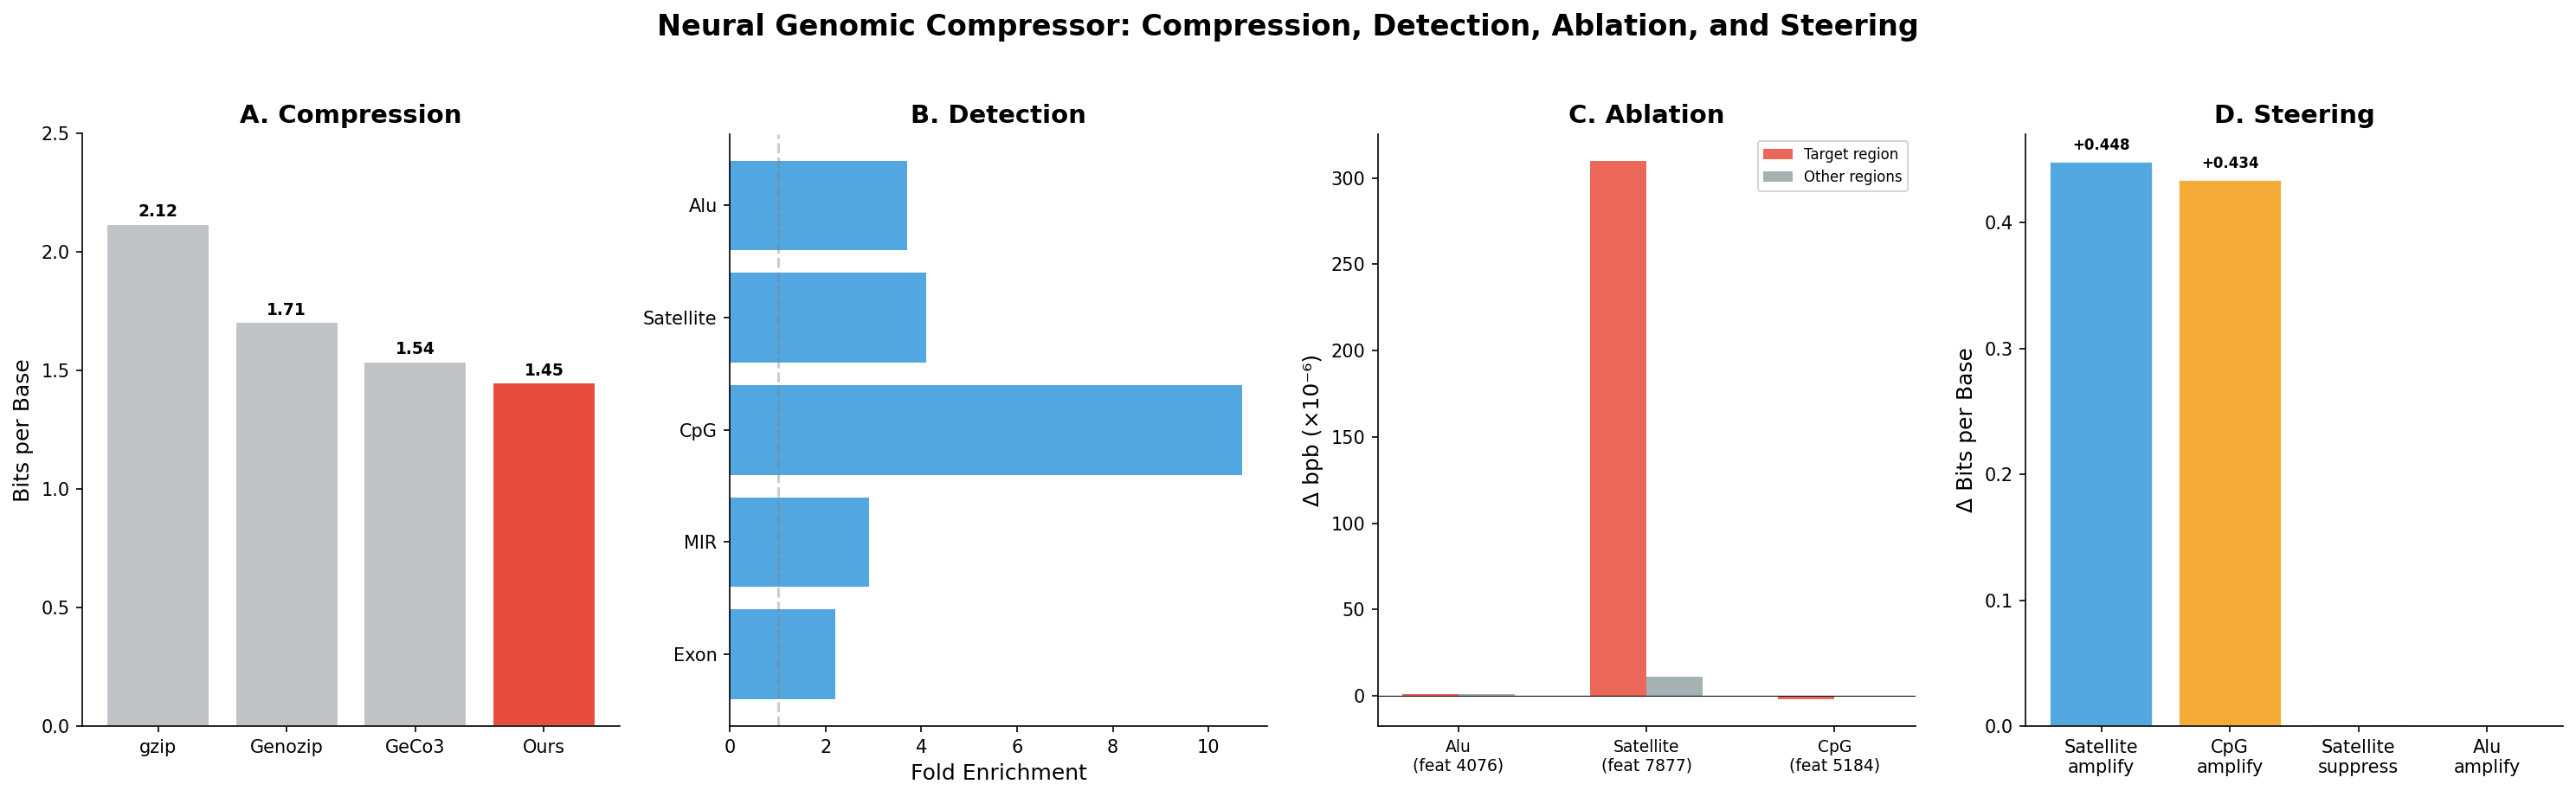

Saved Figure 8.


In [ ]:
fig = plt.figure(figsize=(20, 6))

# Panel A: Compression
ax1 = fig.add_subplot(141)
compressors = ['gzip', 'Genozip', 'GeCo3', 'Ours']
bpb_vals = [2.120, 1.705, 1.539, 1.450]
bar_colors = ['#bdc3c7', '#bdc3c7', '#bdc3c7', '#e74c3c']
ax1.bar(compressors, bpb_vals, color=bar_colors, edgecolor='white')
ax1.set_ylabel('Bits per Base')
ax1.set_title('A. Compression', fontweight='bold')
ax1.set_ylim(0, 2.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for i, v in enumerate(bpb_vals):
    ax1.text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Panel B: Detection
ax2 = fig.add_subplot(142)
det_labels = ['Alu', 'Satellite', 'CpG', 'MIR', 'Exon']
det_precs = [0.63, 0.26, 0.16, 0.11, 0.20]
det_folds = [3.7, 4.1, 10.7, 2.9, 2.2]
ax2.barh(det_labels, det_folds, color='#3498db', alpha=0.85)
ax2.set_xlabel('Fold Enrichment')
ax2.set_title('B. Detection', fontweight='bold')
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.4)
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel C: Ablation
ax3 = fig.add_subplot(143)
abl_labels = ['Alu\n(feat 4076)', 'Satellite\n(feat 7877)', 'CpG\n(feat 5184)']
abl_target = [0.000001, 0.000310, -0.000002]
abl_other = [0.000001, 0.000011, 0.000000]
x_abl = np.arange(len(abl_labels))
ax3.bar(x_abl - 0.15, [v*1e6 for v in abl_target], 0.3,
        label='Target region', color='#e74c3c', alpha=0.85)
ax3.bar(x_abl + 0.15, [v*1e6 for v in abl_other], 0.3,
        label='Other regions', color='#95a5a6', alpha=0.85)
ax3.set_xticks(x_abl)
ax3.set_xticklabels(abl_labels, fontsize=9)
ax3.set_ylabel('Δ bpb (×10⁻⁶)')
ax3.set_title('C. Ablation', fontweight='bold')
ax3.legend(fontsize=8)
ax3.axhline(y=0, color='black', linewidth=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Panel D: Steering
ax4 = fig.add_subplot(144)
steer_labels = ['Satellite\namplify', 'CpG\namplify', 'Satellite\nsuppress', 'Alu\namplify']
steer_bpb = [+0.4482, +0.4337, +0.0006, +0.0000]
steer_colors = ['#3498db', '#f39c12', '#2980b9', '#e74c3c']
ax4.bar(steer_labels, steer_bpb, color=steer_colors, alpha=0.85, edgecolor='white')
ax4.set_ylabel('Δ Bits per Base')
ax4.set_title('D. Steering', fontweight='bold')
ax4.axhline(y=0, color='black', linewidth=0.5)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
for i, v in enumerate(steer_bpb):
    if abs(v) > 0.01:
        ax4.text(i, v + 0.01, f'{v:+.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Neural Genomic Compressor: Compression, Detection, Ablation, and Steering',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig8_summary_panel.png')
plt.savefig(f'{SAVE_DIR}/fig8_summary_panel.pdf')
plt.show()
print('Saved Figure 8.')

In [ ]:
"""
---
## Figure 9: Entropy Profile Across Chr22

Per-position compression cost overlaid with genomic annotations.
Low entropy = model predicts confidently (repetitive/structured regions).
High entropy = model is uncertain (unique/complex regions).
"""

'\n---\n## Figure 9: Entropy Profile Across Chr22\n \nPer-position compression cost overlaid with genomic annotations.\nLow entropy = model predicts confidently (repetitive/structured regions).\nHigh entropy = model is uncertain (unique/complex regions).\n'

In [ ]:
chr22_tokens = np.load('/content/data/chr22.npy')
num_tokens_chr22 = len(chr22_tokens)

print('Computing per-position entropy across chr22...')
print('This may take a few minutes.\n')

all_entropy = []
all_bpb = []
CHUNK_SIZE = 2048

with torch.no_grad():
    for start in range(0, num_tokens_chr22 - 1, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, num_tokens_chr22)
        chunk = torch.tensor(
            chr22_tokens[start:end], dtype=torch.long
        ).unsqueeze(0).to(device)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            output = transformer(chunk)
            logits = output.logits.squeeze(0).float()

        probs = F.softmax(logits[:-1], dim=-1)
        targets = torch.tensor(chr22_tokens[start + 1:end], dtype=torch.long).to(device)

        # Per-position entropy
        entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1).cpu().numpy()
        all_entropy.append(entropy)

        # Per-position bpb
        loss = F.cross_entropy(logits[:-1], targets, reduction='none')
        bpb = (loss / LN2 / 6).cpu().numpy()
        all_bpb.append(bpb)

        if start % (CHUNK_SIZE * 200) == 0:
            print(f'  {start:,} / {num_tokens_chr22:,}')

all_entropy = np.concatenate(all_entropy)
all_bpb = np.concatenate(all_bpb)
print(f'\nDone. {len(all_entropy):,} positions.')
print(f'Mean entropy: {all_entropy.mean():.2f} bits')
print(f'Mean bpb: {all_bpb.mean():.4f}')

Computing per-position entropy across chr22...
This may take a few minutes.

  0 / 6,526,630
  409,600 / 6,526,630
  819,200 / 6,526,630
  1,228,800 / 6,526,630
  1,638,400 / 6,526,630
  2,048,000 / 6,526,630
  2,457,600 / 6,526,630
  2,867,200 / 6,526,630
  3,276,800 / 6,526,630
  3,686,400 / 6,526,630
  4,096,000 / 6,526,630
  4,505,600 / 6,526,630
  4,915,200 / 6,526,630
  5,324,800 / 6,526,630
  5,734,400 / 6,526,630
  6,144,000 / 6,526,630

Done. 6,523,443 positions.
Mean entropy: 8.67 bits
Mean bpb: 1.4482


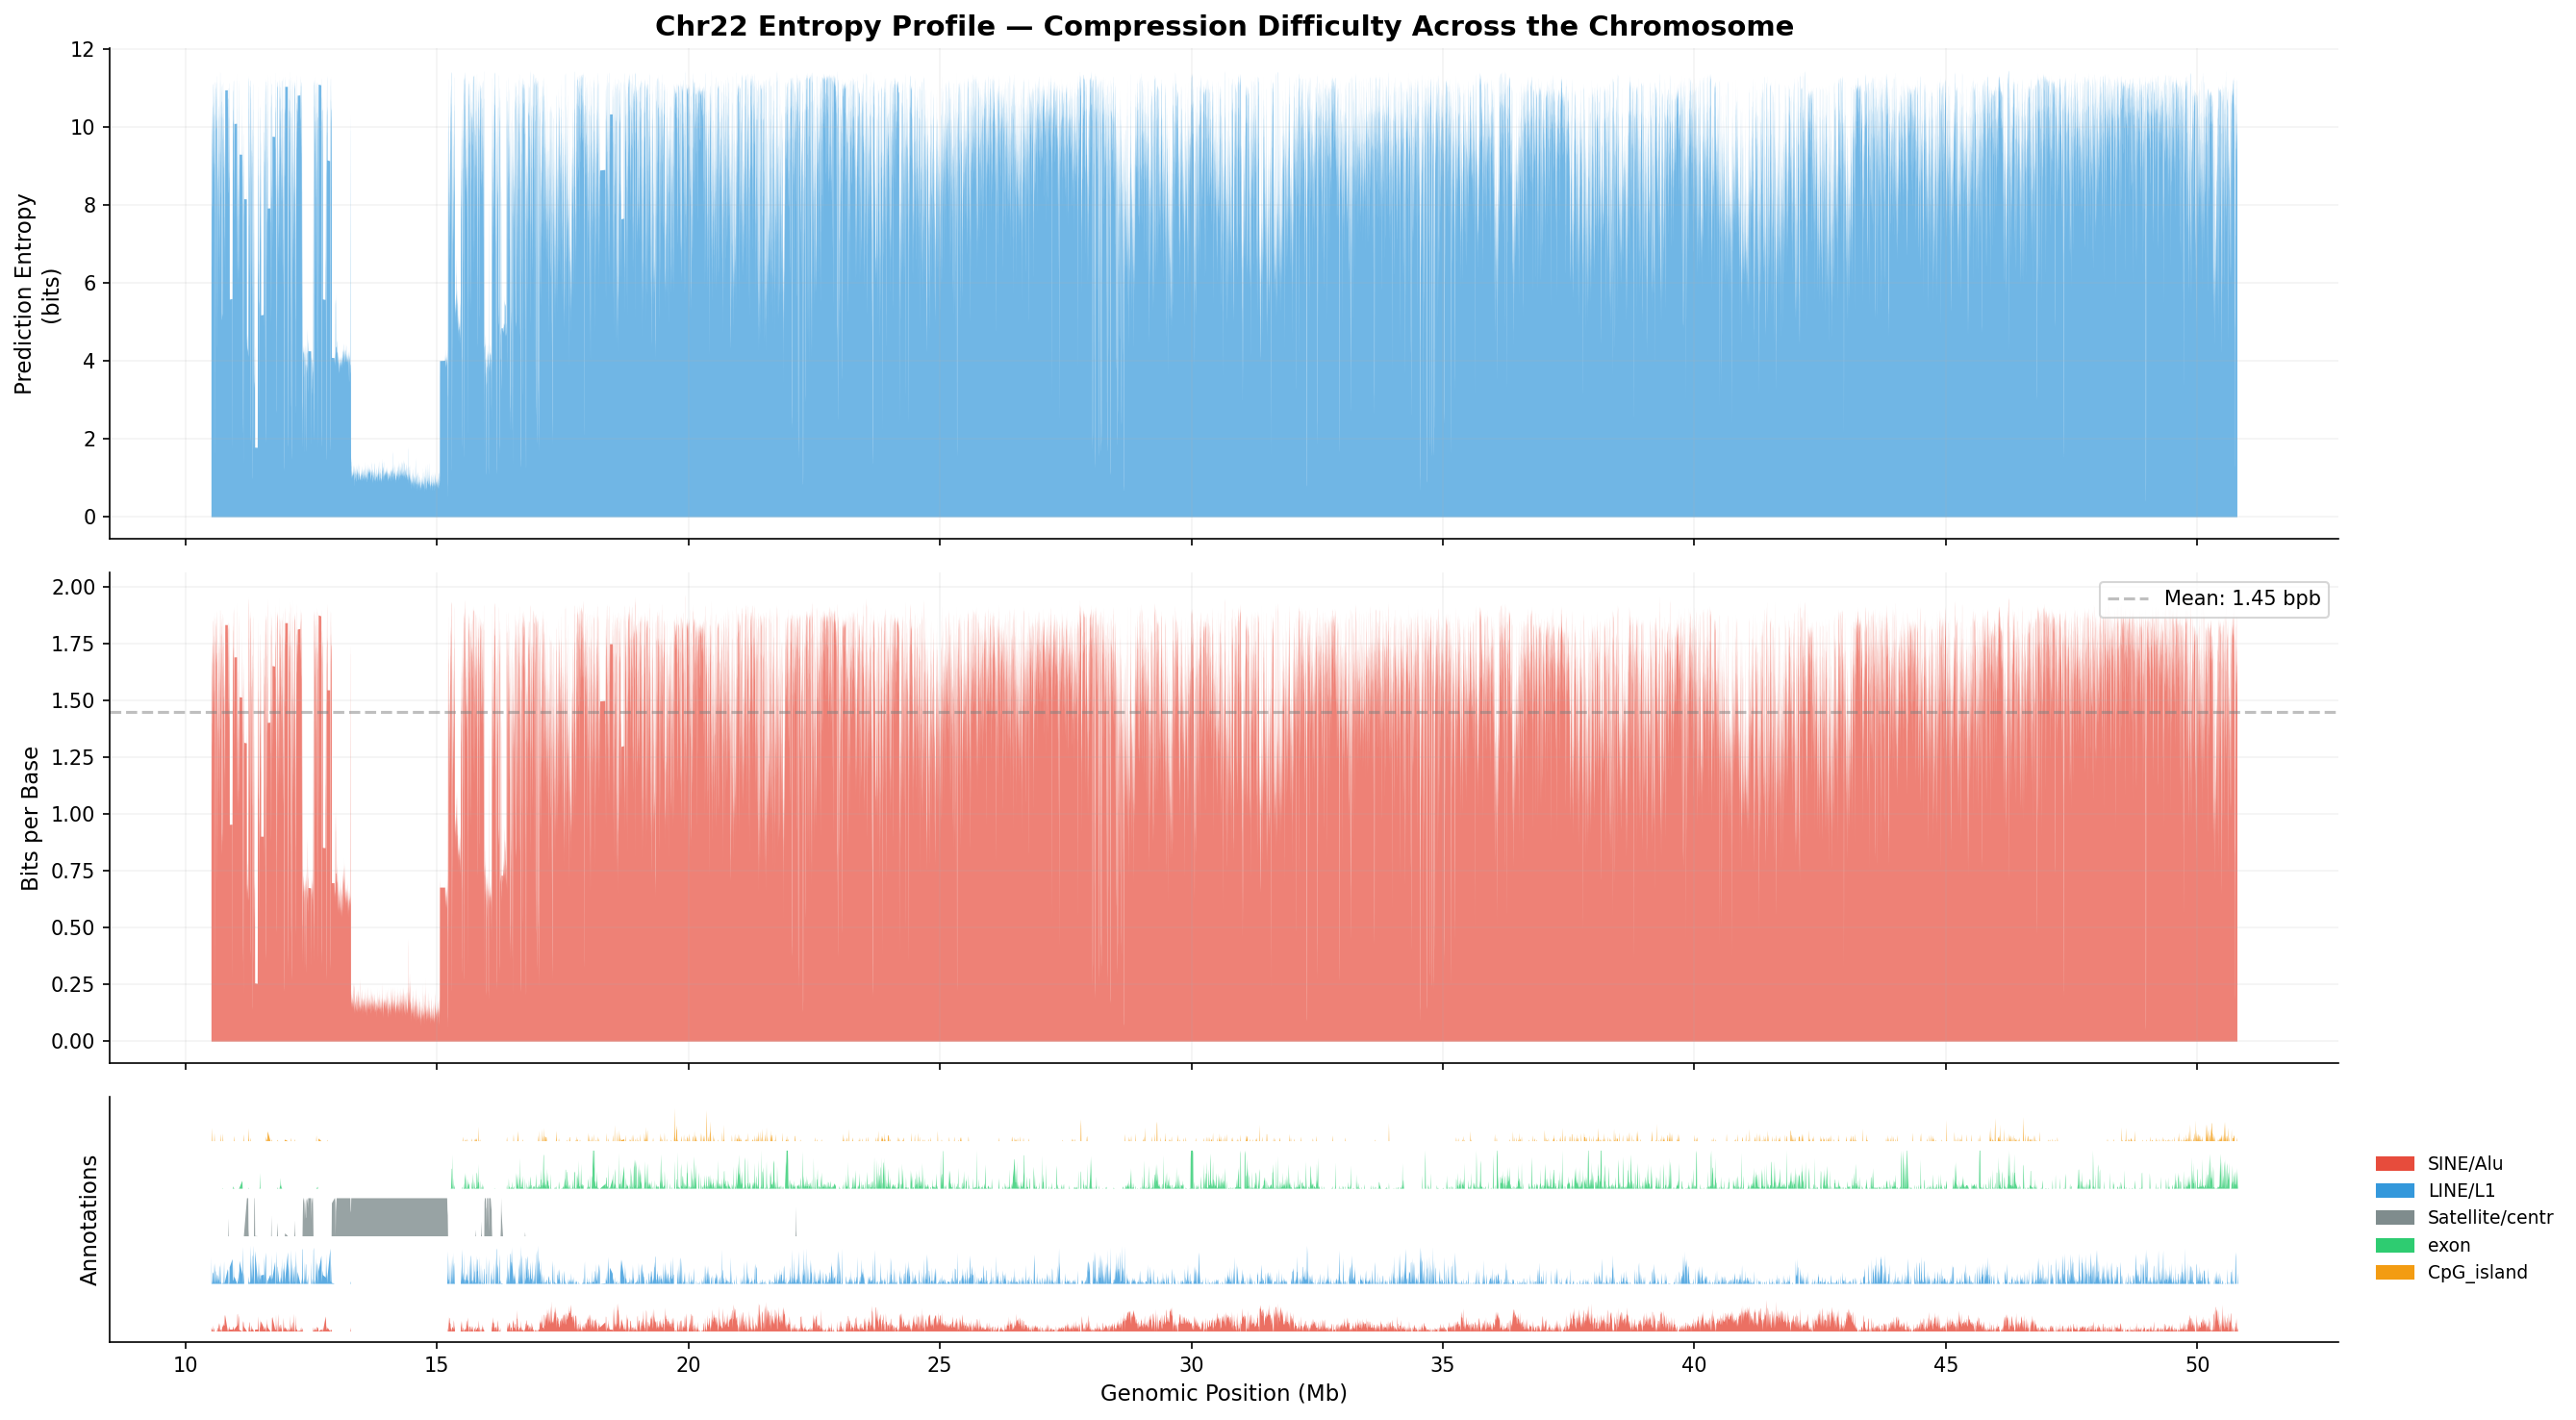

Saved Figure 9.


In [ ]:

# Get reference positions for x-axis
token_ref_starts = np.load('/content/data/chr22_ref_positions_tokens.npy')

# Smooth for visualization (rolling average)
window = 500
entropy_smooth = np.convolve(all_entropy, np.ones(window)/window, mode='valid')
bpb_smooth = np.convolve(all_bpb, np.ones(window)/window, mode='valid')

# Reference positions for smoothed data
ref_pos_smooth = token_ref_starts[:len(entropy_smooth)] / 1e6  # Megabases

fig, axes = plt.subplots(3, 1, figsize=(18, 10), height_ratios=[2, 2, 1], sharex=True)

# Entropy track
axes[0].fill_between(ref_pos_smooth, entropy_smooth, alpha=0.7, color='#3498db', linewidth=0)
axes[0].set_ylabel('Prediction Entropy\n(bits)', fontsize=11)
axes[0].set_title('Chr22 Entropy Profile — Compression Difficulty Across the Chromosome',
                   fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# BPB track
axes[1].fill_between(ref_pos_smooth, bpb_smooth, alpha=0.7, color='#e74c3c', linewidth=0)
axes[1].set_ylabel('Bits per Base', fontsize=11)
axes[1].axhline(y=all_bpb.mean(), color='gray', linestyle='--', alpha=0.5,
                label=f'Mean: {all_bpb.mean():.2f} bpb')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Annotation track
annotation_colors = {
    'SINE/Alu': '#e74c3c',
    'LINE/L1': '#3498db',
    'Satellite/centr': '#7f8c8d',
    'exon': '#2ecc71',
    'CpG_island': '#f39c12',
}

legend_patches = []
y_pos = 0
n_labels = len(annotation_colors)

# For full chromosome, use a density approach instead of individual tokens
for label, color in annotation_colors.items():
    annotated = ann.get_tokens(label)
    if len(annotated) == 0:
        continue

    # Bin the annotations into windows
    bin_size = 1000  # tokens per bin
    n_bins = num_tokens_chr22 // bin_size
    density = np.zeros(n_bins)
    for idx in annotated:
        b = idx // bin_size
        if b < n_bins:
            density[b] += 1
    density = density / bin_size  # fraction

    bin_positions = token_ref_starts[::bin_size][:n_bins] / 1e6

    axes[2].fill_between(bin_positions, y_pos, y_pos + density * 0.8,
                         alpha=0.8, color=color, linewidth=0)
    legend_patches.append(mpatches.Patch(color=color, label=label))
    y_pos += 1

axes[2].set_ylabel('Annotations', fontsize=11)
axes[2].set_xlabel('Genomic Position (Mb)', fontsize=11)
axes[2].set_yticks([])
axes[2].legend(handles=legend_patches, loc='center left',
               bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig9_entropy_profile.png')
plt.savefig(f'{SAVE_DIR}/fig9_entropy_profile.pdf')
plt.show()
print('Saved Figure 9.')

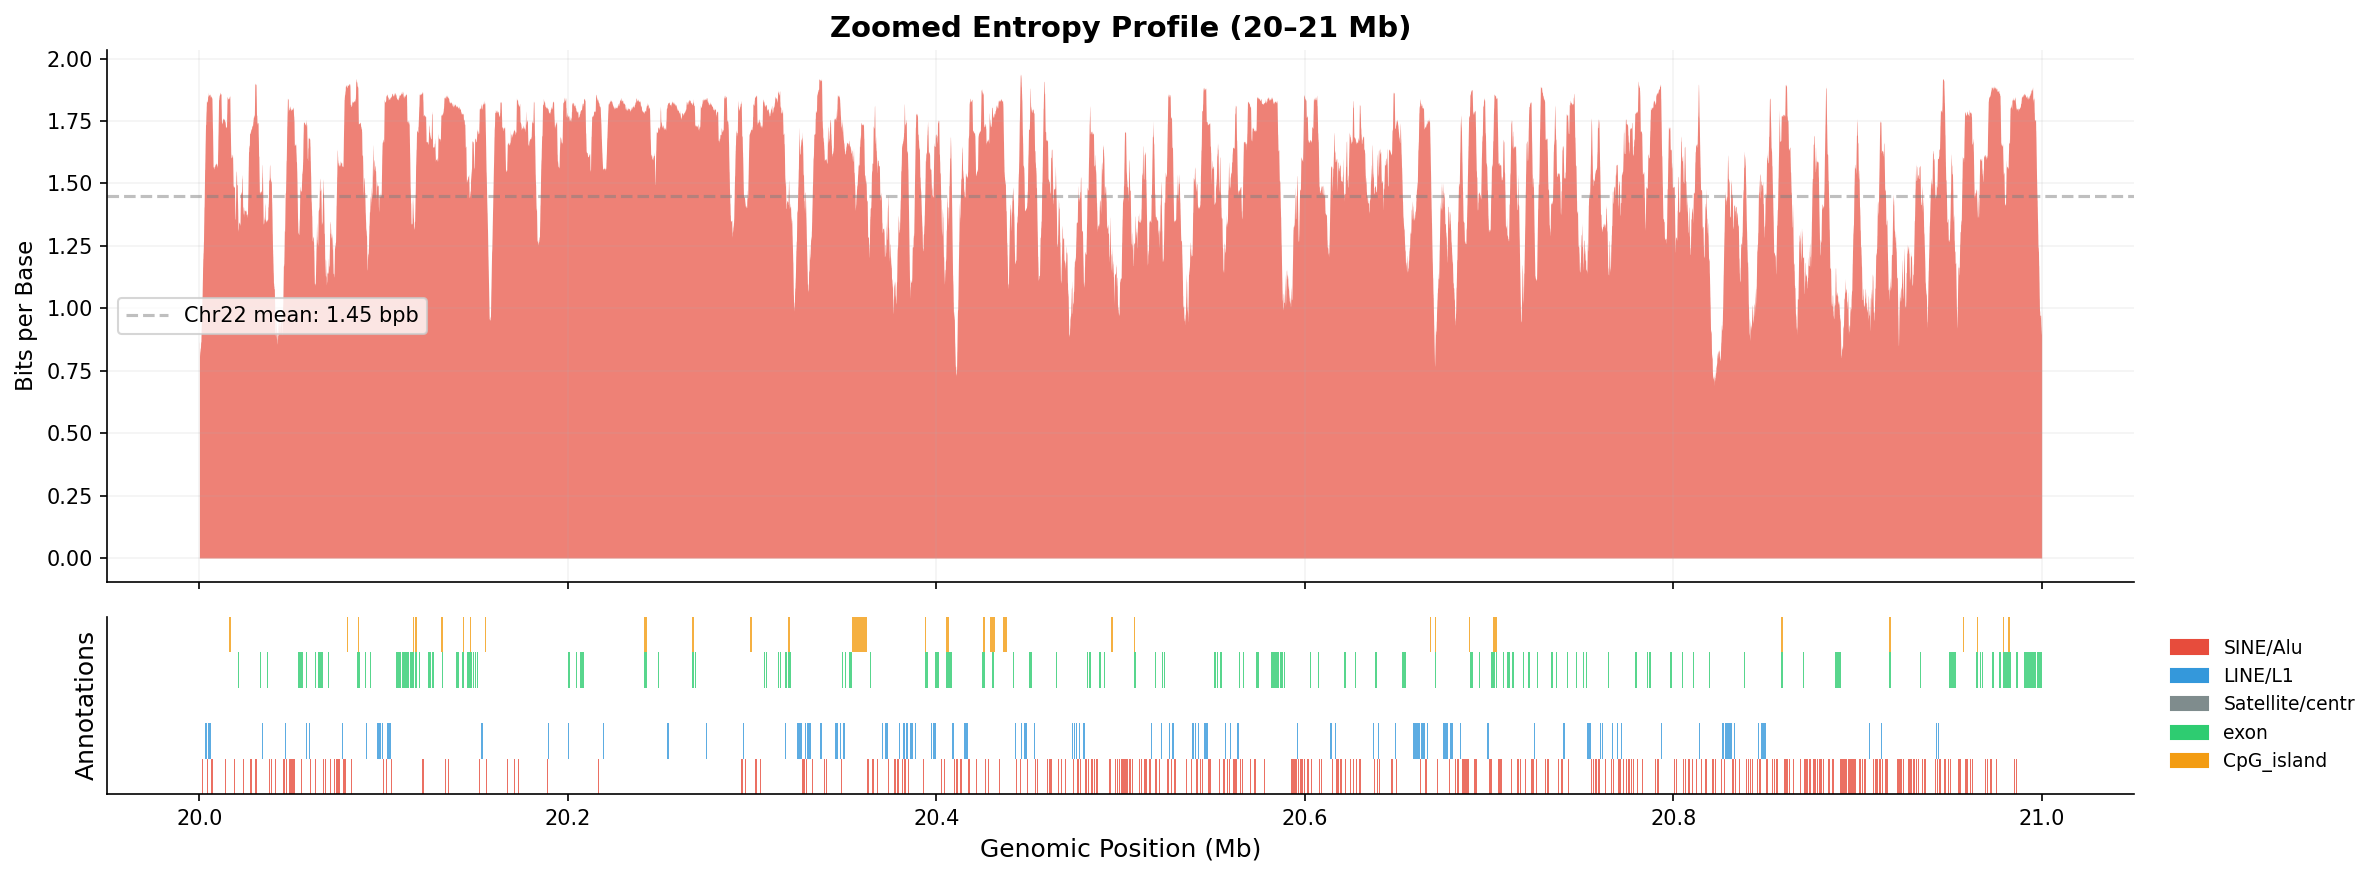

Saved Figure 9b.


In [ ]:
# Find a region with mixed annotations (Alu + exon + unannotated)
# Use a region around 20Mb which typically has gene-rich areas
zoom_start_ref = 20.0  # Mb
zoom_end_ref = 21.0    # Mb

mask = (ref_pos_smooth >= zoom_start_ref) & (ref_pos_smooth <= zoom_end_ref)
zoom_ref = ref_pos_smooth[mask]
zoom_entropy = entropy_smooth[mask]
zoom_bpb = bpb_smooth[mask]

fig, axes = plt.subplots(2, 1, figsize=(16, 6), height_ratios=[3, 1], sharex=True)

axes[0].fill_between(zoom_ref, zoom_bpb, alpha=0.7, color='#e74c3c', linewidth=0)
axes[0].set_ylabel('Bits per Base', fontsize=11)
axes[0].set_title(f'Zoomed Entropy Profile ({zoom_start_ref:.0f}–{zoom_end_ref:.0f} Mb)',
                   fontsize=14, fontweight='bold')
axes[0].axhline(y=all_bpb.mean(), color='gray', linestyle='--', alpha=0.5,
                label=f'Chr22 mean: {all_bpb.mean():.2f} bpb')
axes[0].legend()
axes[0].grid(True, alpha=0.15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Annotation track for zoomed region
zoom_token_start = np.searchsorted(token_ref_starts / 1e6, zoom_start_ref)
zoom_token_end = np.searchsorted(token_ref_starts / 1e6, zoom_end_ref)
zoom_tokens = np.arange(zoom_token_start, zoom_token_end)
zoom_token_refs = token_ref_starts[zoom_token_start:zoom_token_end] / 1e6

legend_patches = []
y_pos = 0
for label, color in annotation_colors.items():
    annotated_set = set(ann.get_tokens(label).tolist())
    for t_idx, ref_pos in zip(zoom_tokens, zoom_token_refs):
        if int(t_idx) in annotated_set:
            axes[1].axvspan(ref_pos, ref_pos + 6/1e6,
                           ymin=y_pos/n_labels, ymax=(y_pos+1)/n_labels,
                           alpha=0.8, color=color, linewidth=0)
    legend_patches.append(mpatches.Patch(color=color, label=label))
    y_pos += 1

axes[1].set_ylabel('Annotations')
axes[1].set_xlabel('Genomic Position (Mb)')
axes[1].set_yticks([])
axes[1].legend(handles=legend_patches, loc='center left',
               bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig9b_entropy_profile_zoomed.png')
plt.savefig(f'{SAVE_DIR}/fig9b_entropy_profile_zoomed.pdf')
plt.show()
print('Saved Figure 9b.')


In [ ]:
"""
---
## Figure 10: UMAP of Hidden States by Region Type

Project hidden states to 2D using UMAP, colored by genomic annotation.
If the model learned meaningful representations, different region types
should cluster separately.
"""

'\n---\n## Figure 10: UMAP of Hidden States by Region Type\n \nProject hidden states to 2D using UMAP, colored by genomic annotation.\nIf the model learned meaningful representations, different region types\nshould cluster separately.\n'

In [ ]:
!pip install umap-learn -q

In [ ]:
import umap

# Sample hidden states — UMAP can't handle 6.5M points
N_SAMPLE = 50000
np.random.seed(42)
sample_indices = np.random.choice(num_tokens, N_SAMPLE, replace=False)
sample_indices.sort()

sample_hidden = hidden_states[sample_indices].numpy()

# Assign labels to each sampled token
label_priority = [
    ('Satellite/centr', '#7f8c8d'),
    ('SINE/Alu', '#e74c3c'),
    ('LINE/L1', '#3498db'),
    ('LTR/ERVL-MaLR', '#8e44ad'),
    ('exon', '#2ecc71'),
    ('CpG_island', '#f39c12'),
    ('Simple_repeat', '#e67e22'),
]

# Build label sets
label_sets = {}
for label, color in label_priority:
    label_sets[label] = set(ann.get_tokens(label).tolist())

# Assign each sampled token a label (first match wins, or 'Other')
sample_labels = []
sample_colors = []
other_color = '#d5dbdb'

for idx in sample_indices:
    idx_int = int(idx)
    found = False
    for label, color in label_priority:
        if idx_int in label_sets[label]:
            sample_labels.append(label)
            sample_colors.append(color)
            found = True
            break
    if not found:
        sample_labels.append('Other')
        sample_colors.append(other_color)

sample_labels = np.array(sample_labels)
sample_colors = np.array(sample_colors)

print(f'Sample size: {N_SAMPLE:,}')
for label, _ in label_priority:
    count = (sample_labels == label).sum()
    print(f'  {label:<25} {count:>6,} ({100*count/N_SAMPLE:.1f}%)')
other_count = (sample_labels == 'Other').sum()
print(f'  {"Other":<25} {other_count:>6,} ({100*other_count/N_SAMPLE:.1f}%)')

print('\nRunning UMAP... (this takes 2-5 minutes)')
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    n_components=2,
    metric='cosine',
    random_state=42,
)
embedding = reducer.fit_transform(sample_hidden)
print('UMAP complete.')

Sample size: 50,000
  Satellite/centr            3,159 (6.3%)
  SINE/Alu                   8,367 (16.7%)
  LINE/L1                    5,738 (11.5%)
  LTR/ERVL-MaLR              1,333 (2.7%)
  exon                       3,959 (7.9%)
  CpG_island                   400 (0.8%)
  Simple_repeat                759 (1.5%)
  Other                     26,285 (52.6%)

Running UMAP... (this takes 2-5 minutes)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete.


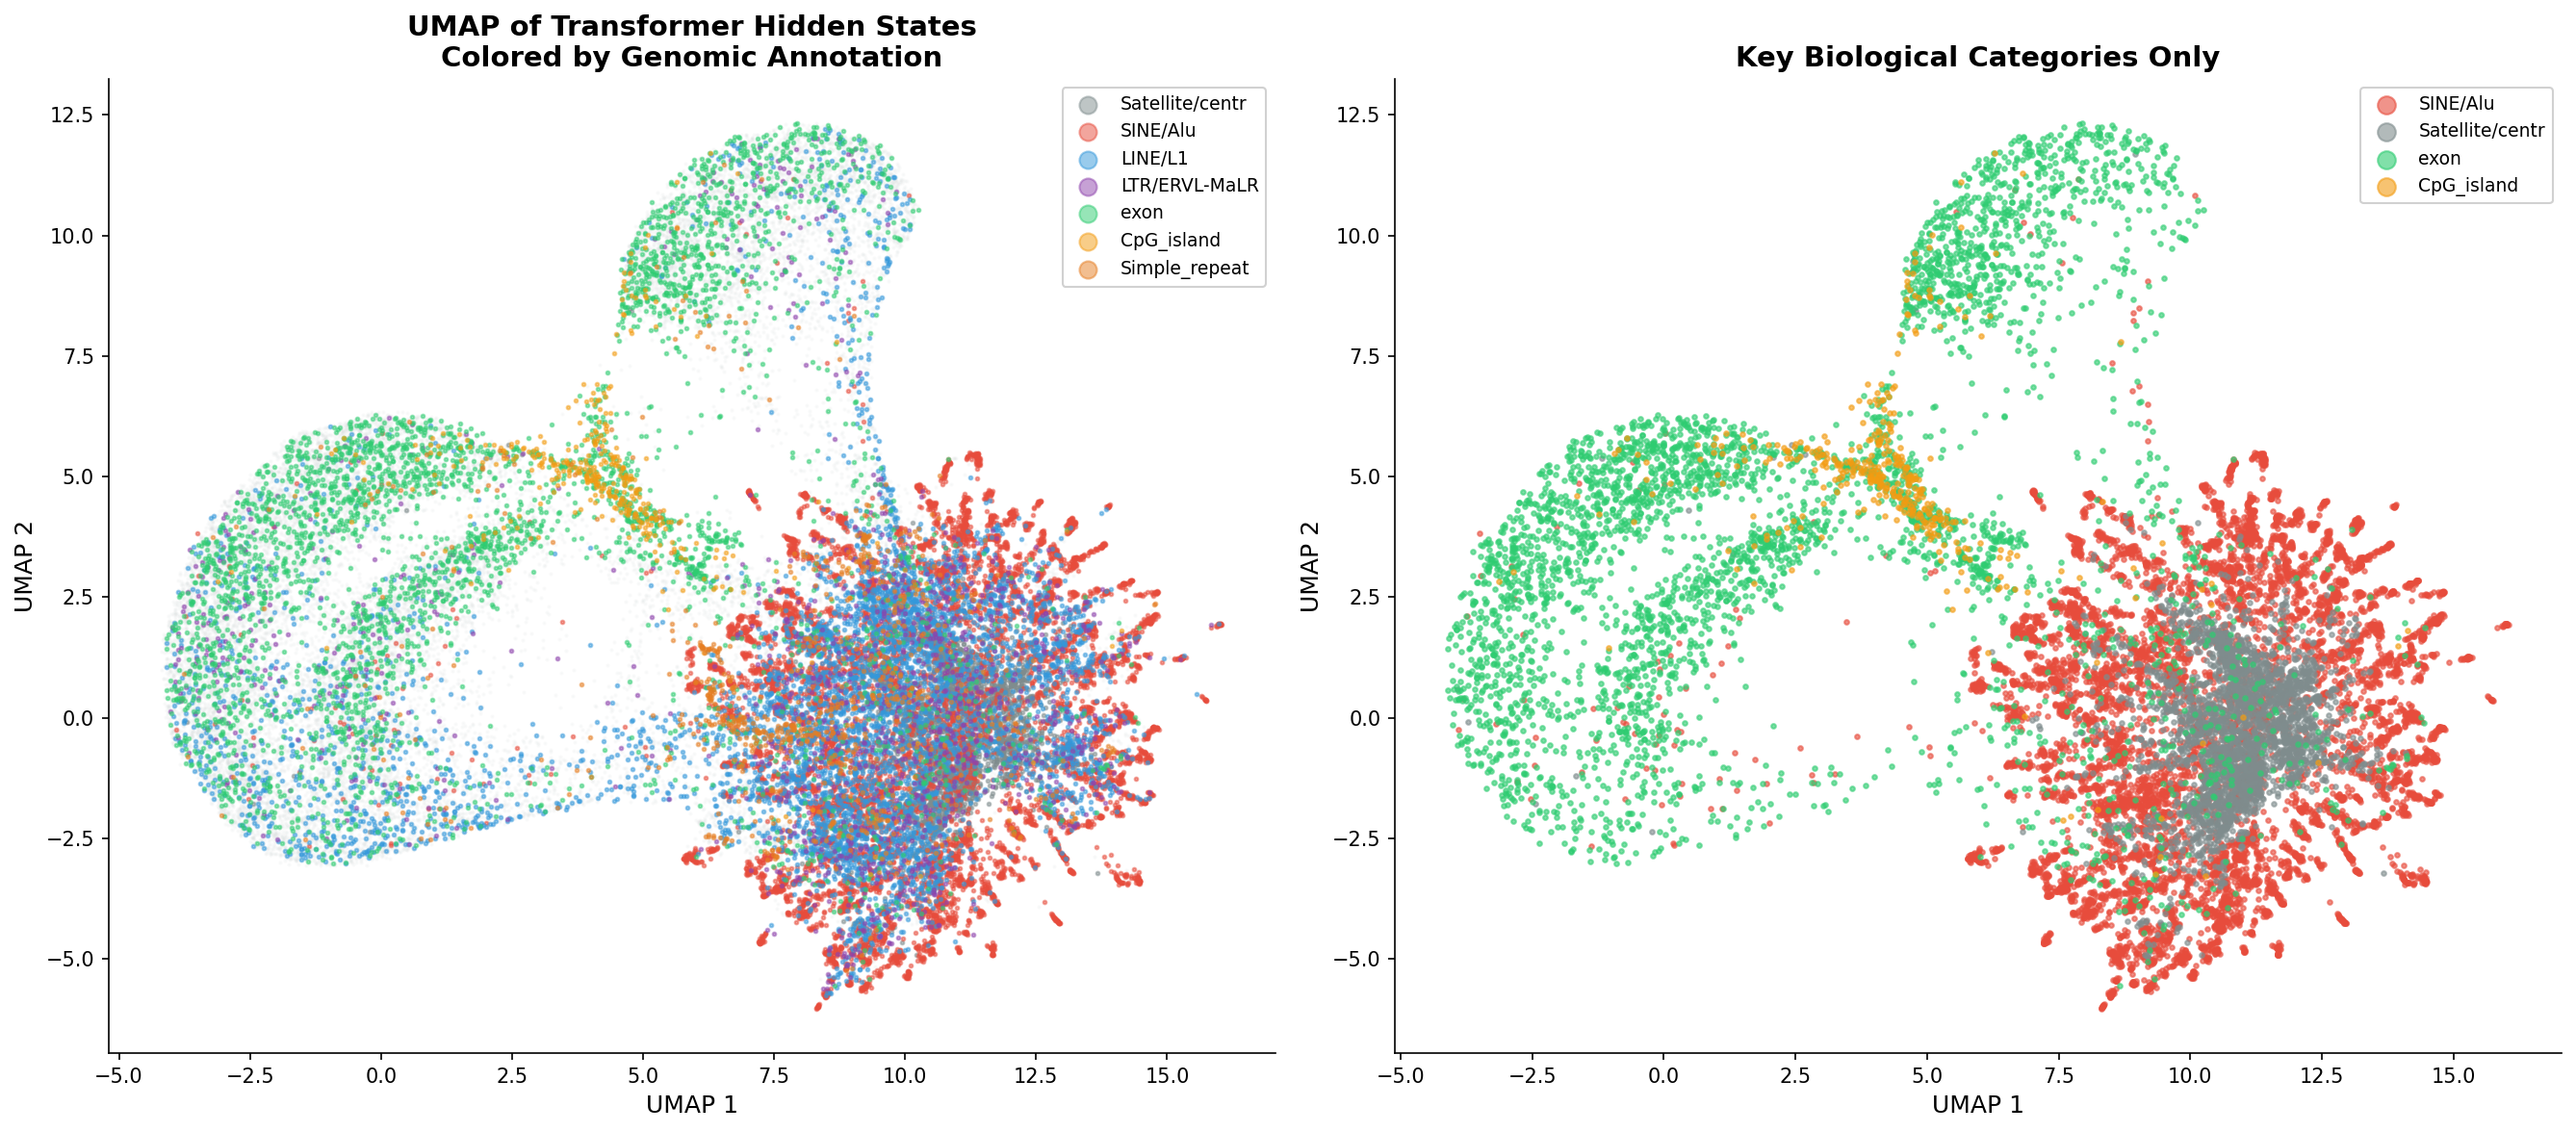

Saved Figure 10.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: all points, Other in background
# Plot 'Other' first so it's behind
other_mask = sample_labels == 'Other'
axes[0].scatter(embedding[other_mask, 0], embedding[other_mask, 1],
                c=other_color, s=1, alpha=0.1, rasterized=True)

# Plot annotated points on top
for label, color in label_priority:
    mask = sample_labels == label
    if mask.sum() > 0:
        axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                        c=color, s=3, alpha=0.5, label=label, rasterized=True)

axes[0].set_title('UMAP of Transformer Hidden States\nColored by Genomic Annotation',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(loc='upper right', fontsize=9, markerscale=5, framealpha=0.9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: only key categories, cleaner view
for label, color in [('SINE/Alu', '#e74c3c'), ('Satellite/centr', '#7f8c8d'),
                     ('exon', '#2ecc71'), ('CpG_island', '#f39c12')]:
    mask = sample_labels == label
    if mask.sum() > 0:
        axes[1].scatter(embedding[mask, 0], embedding[mask, 1],
                        c=color, s=5, alpha=0.6, label=label, rasterized=True)

axes[1].set_title('Key Biological Categories Only',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(loc='upper right', fontsize=9, markerscale=4, framealpha=0.9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig10_umap_hidden_states.png')
plt.savefig(f'{SAVE_DIR}/fig10_umap_hidden_states.pdf')
plt.show()
print('Saved Figure 10.')


Computing SAE activations for sampled tokens...
SAE activations shape: (50000, 8192)
Running UMAP on SAE activations...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


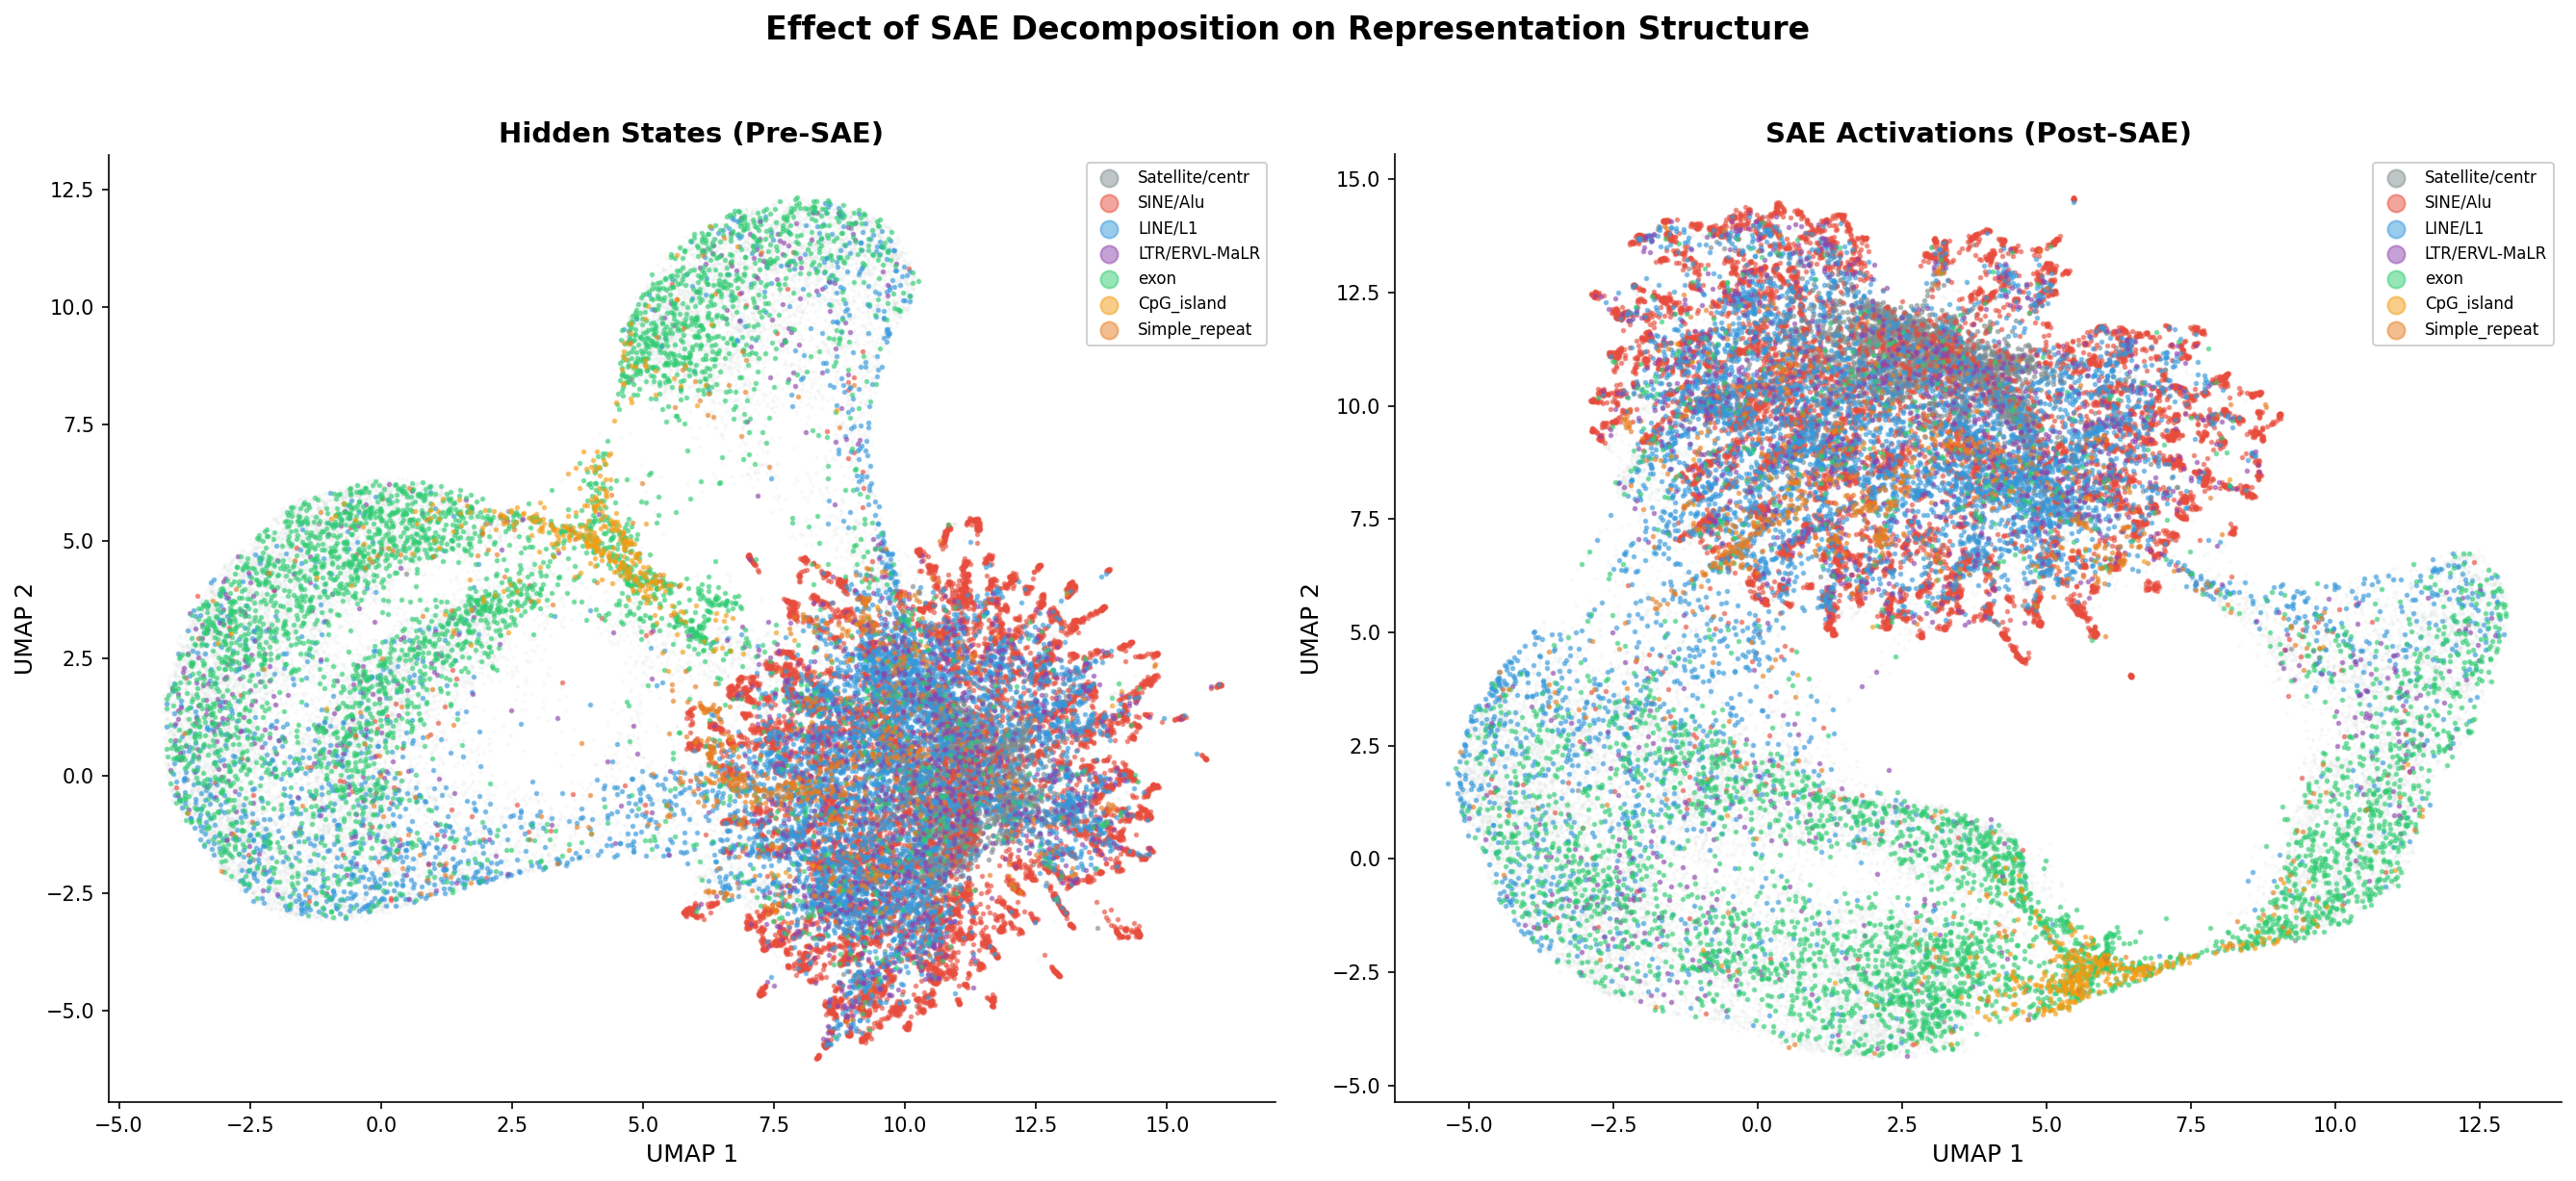

Saved Figure 10b.


In [ ]:
print('Computing SAE activations for sampled tokens...')
sample_hidden_tensor = torch.tensor(sample_hidden, dtype=torch.float32)

sae_activations = []
with torch.no_grad():
    for i in range(0, N_SAMPLE, 4096):
        batch = sample_hidden_tensor[i:i+4096].to(device)
        z = sae.encode(batch).cpu()
        sae_activations.append(z)

sae_activations = torch.cat(sae_activations, dim=0).numpy()
print(f'SAE activations shape: {sae_activations.shape}')

print('Running UMAP on SAE activations...')
reducer_sae = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    n_components=2,
    metric='cosine',
    random_state=42,
)
embedding_sae = reducer_sae.fit_transform(sae_activations)
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Hidden state UMAP
other_mask = sample_labels == 'Other'
axes[0].scatter(embedding[other_mask, 0], embedding[other_mask, 1],
                c=other_color, s=1, alpha=0.1, rasterized=True)
for label, color in label_priority:
    mask = sample_labels == label
    if mask.sum() > 0:
        axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                        c=color, s=3, alpha=0.5, label=label, rasterized=True)
axes[0].set_title('Hidden States (Pre-SAE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(loc='upper right', fontsize=8, markerscale=5, framealpha=0.9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# SAE activation UMAP
axes[1].scatter(embedding_sae[other_mask, 0], embedding_sae[other_mask, 1],
                c=other_color, s=1, alpha=0.1, rasterized=True)
for label, color in label_priority:
    mask = sample_labels == label
    if mask.sum() > 0:
        axes[1].scatter(embedding_sae[mask, 0], embedding_sae[mask, 1],
                        c=color, s=3, alpha=0.5, label=label, rasterized=True)
axes[1].set_title('SAE Activations (Post-SAE)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(loc='upper right', fontsize=8, markerscale=5, framealpha=0.9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Effect of SAE Decomposition on Representation Structure',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig10b_umap_comparison.png')
plt.savefig(f'{SAVE_DIR}/fig10b_umap_comparison.pdf')
plt.show()
print('Saved Figure 10b.')

---
## Summary

In [ ]:
print('=' * 60)
print('ALL FIGURES GENERATED')
print('=' * 60)
print(f'\nSaved to: {SAVE_DIR}')
print(f'\nFigures:')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1024
    print(f'  {f:<45s} {size:.0f} KB')

ALL FIGURES GENERATED

Saved to: /content/figures

Figures:
  fig10_umap_hidden_states.pdf                  4112 KB
  fig10_umap_hidden_states.png                  4931 KB
  fig10b_umap_comparison.pdf                    6184 KB
  fig10b_umap_comparison.png                    6389 KB
  fig1_compression_comparison.pdf               23 KB
  fig1_compression_comparison.png               100 KB
  fig2_feature_frequency.pdf                    25 KB
  fig2_feature_frequency.png                    145 KB
  fig3a_alu_detector_track.pdf                  102 KB
  fig3a_alu_detector_track.png                  188 KB
  fig3b_satellite_detector_track.pdf            174 KB
  fig3b_satellite_detector_track.png            672 KB
  fig3c_cpg_detector_track.pdf                  121 KB
  fig3c_cpg_detector_track.png                  210 KB
  fig4_feature_catalog.pdf                      24 KB
  fig4_feature_catalog.png                      123 KB
  fig5_ablation_results.pdf                     28 KB
  fig

In [ ]:
!cp -r /content/figures/ /content/drive/MyDrive/genomic_compressor/figures/